<h1 style="text-align: center;">Big Data Analysis </h1>
<h1 style="text-align: center;"> 3803ICT </h1>

<h3 style="text-align: center;"> Denis Chizhov s5275427 </h3>
<h4 style="text-align: center;"> denis.chizhov@griffithuni.edu.au </h4>

## Table of Contents

- Part 1 – Data Preparation and Preprocessing
  - 1.1 Describe the Dataset
  - 1.2 Normalize and Clean the Data
    - Calculate the Average Salary
    - Clean Id Column Using Regex
    - Clean Date Using Regex
    - Get the Data Range of the Database
    - Get the Number of Variations for Each Attribute
    - Change Type of Related Columns
    - Delete ID Column
    - Delete Duplicates
    - Visualize Missing Data
    - Handle Missing Data and Trim Dataset
  - 1.3 Job Metadata
    - Sectors and Subsectors
    - Locations
    - Salary Range and Job Type

- Part 2 – Data Analysis and Interpretation
  - 2.1 Study the Market by Locations
    - Market Size by City
    - Market Share Between Cities
    - Salary Distribution in Top Cities
    - Hot Sectors in Top Cities
    - Job Posting Patterns by Day of Month
    - Clustering Cities by Market Size and Salary
    - Interactive Visualization of Job Postings vs Salary
    - Job Posting Patterns by Weekday and Month
  - 2.2 Study by Sectors
    - Market Share by Sector
    - Most Prevalent Sub-Sectors
    - Median Salaries Across Sectors
    - Salary Variance in Top Sectors
    - Interactive Visualizations
    - Skills Analysis by Sector
    - Salary Distribution by Sub-Sectors
    - Top Required Skills by Sector and Sub-Sector

- Part 3 – Evaluation
  - Key Findings
  - Actions to Balance the Market
  - Refining the Analytics
  - Implications for Employers and Employees

- Part 4 – Case Studies
  - Case Study 1
  - Case Study 2

# Part 1 – Data Preparation and Preprocessing

In [1]:
import pandas as pd
import calendar
import numpy as np
import seaborn as sns
from collections import Counter
from IPython.display import HTML, display
import plotly.express as px
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from wordcloud import WordCloud

sns.set()
sns.set_style("whitegrid")

display(HTML("<style>.container { width:75% !important; }</style>"))

## 1.1 Describe the dataset

The dataset offers a detailed snapshot of job postings across Australia from October 1, 2018, to March 13, 2019 - a total of 318,477 entries spanning 13 columns. It reads like a cross-section of the employment landscape, featuring everything from job titles and companies to locations, sectors, sub-sectors, salary brackets, job types, and descriptions.
Certain categories stand out: Information & Communication Technology leads with 22,756 postings, followed by Trades & Services (17,876) and Healthcare & Medical (16,992). Unsurprisingly, the urban heavyweights Sydney and Melbourne dominate the geography, with 60,765 and 46,690 listings respectively.
Structured as a CSV file, the dataset includes attributes such as Id (a unique identifier), Title, Company, Date, Location, Area, Classification, SubClassification, Requirement, FullDescription, LowestSalary, HighestSalary, and JobType.
It’s worth noting that the dataset is not without its imperfections. Some columns show missing values - most notably Location (38.07%) and Area (61.49%), while Company and JobType are missing in 3.77% and 5.05% of records, respectively. For cleaner analysis, a trimmed version of the dataset - up to December 15, 2018 - is used to sidestep the most incomplete entries in Location, Classification, and SubClassification.
Key features such as Classification, Location, JobType, and a newly computed average_salary (based on the mean of Lowest and Highest salary) serve as the backbone of the analysis, helping to uncover patterns in salary distribution, regional demand, and broader market dynamics.


### Load the dataset using pd.read_csv

In [2]:
%%capture --no-display --no-stdout
df = pd.read_csv('data.csv')

### Visualize the head of dataset to describe its properties

In [3]:
unique_counts = pd.DataFrame({
    'Attribute': df.columns,
    'No. of Variations': df.nunique().values
})

display(unique_counts)

print("The Dataset consists of: ", df.shape[0], " rows and ", df.shape[1], " columuns")
df.head(10)

,Attribute,No. of Variations
0,Id,318477
1,Title,168065
2,Company,40628
3,Date,163
4,Location,65
5,Area,19
6,Classification,30
7,SubClassification,338
8,Requirement,234287
9,FullDescription,250901


The Dataset consists of:  318477  rows and  13  columuns


,Id,Title,Company,Date,Location,Area,Classification,SubClassification,Requirement,FullDescription,LowestSalary,HighestSalary,JobType
0,37404348,Casual Stock Replenisher,Aldi Stores,2018-10-07T00:00:00.000Z,Sydney,North West & Hills District,Retail & Consumer Products,Retail Assistants,Our Casual Stock Replenishers pride themselves...,NaN,0,30,NaN
1,37404337,Casual Stock Replenisher,Aldi Stores,2018-10-07T00:00:00.000Z,Richmond & Hawkesbury,NaN,Retail & Consumer Products,Retail Assistants,Our Casual Stock Replenishers pride themselves...,NaN,0,30,NaN
2,37404356,RETAIL SALES SUPERSTARS and STYLISTS Wanted - ...,LB Creative Pty Ltd,2018-10-07T00:00:00.000Z,Brisbane,CBD & Inner Suburbs,Retail & Consumer Products,Retail Assistants,BRAND NEW FLAGSHIP STORE OPENING - SUNSHINE PLAZA,NaN,0,30,NaN
3,37404330,Team member - Belrose,Anaconda Group Pty Ltd,2018-10-07T00:00:00.000Z,Gosford & Central Coast,NaN,Retail & Consumer Products,Retail Assistants,Bring it on - do you love the great outdoors a...,NaN,0,30,NaN
4,37404308,"Business Banking Contact Centre Specialist, Ni...",Commonwealth Bank - Business & Private Banking,2018-10-07T00:00:00.000Z,Sydney,Ryde & Macquarie Park,Call Centre & Customer Service,Sales - Inbound,"We are seeking highly articulate, enthusiastic...",NaN,0,30,NaN
5,37404307,"Business Banking Contact Centre Specialist, Ni...",Commonwealth Bank - Business & Private Banking,2018-10-07T00:00:00.000Z,Sydney,Ryde & Macquarie Park,Call Centre & Customer Service,Customer Service - Call Centre,"We are seeking highly articulate, enthusiastic...",NaN,0,30,NaN
6,37404355,Casual Café All-rounder in Semaphore,Jora Local,2018-10-07T00:00:00.000Z,Adelaide,NaN,Hospitality & Tourism,Waiting Staff,A cafe/restaurant in Semaphore is seeking a ca...,NaN,0,30,NaN
7,37404350,Casual Café All-rounder in Woolloongabba,Jora Local,2018-10-07T00:00:00.000Z,Brisbane,CBD & Inner Suburbs,Hospitality & Tourism,Waiting Staff,A cafe in Woolloongabba is seeking a casual Ca...,NaN,0,30,NaN
8,37404301,Telemarketer,Reventon Investments,2018-10-07T00:00:00.000Z,Melbourne,CBD & Inner Suburbs,Call Centre & Customer Service,Sales - Outbound,Market leading investment & financial services...,NaN,0,30,NaN
9,37404286,Casual Dish Hand in Brighton,Jora Local,2018-10-07T00:00:00.000Z,Melbourne,Bayside & South Eastern Suburbs,Hospitality & Tourism,Kitchen & Sandwich Hands,A restaurant in Brighton is seeking a casual D...,NaN,0,30,NaN


## 1.2.Normalize and clean the data.

Data preparation began with loading the dataset using Pandas via pd.read_csv('data.csv'), importing 318,477 rows and 13 columns into a DataFrame. Initial exploration involved checking the dataset's shape and displaying the first 10 rows with df.head(10) to verify its structure. Normalization included cleaning the Id column by converting it to a string, removing non-numeric characters using regex (str.replace(r'&.*', '', regex=True) and str.replace(r'\D+', '', regex=True)), and converting it back to int64. The Date column was standardized by removing time components with regex (str.replace(r'T.*', '', regex=True)) and converted to datetime64 format using pd.to_datetime. A new average_salary column was created using df.assign(avg_salary=lambda x: (x['LowestSalary'] + x['HighestSalary'])/2) to facilitate salary analysis.

Cleaning addressed duplicates and missing data. A total of 8,607 full duplicates were identified using df.duplicated(), with an additional 3,570 duplicates found when ignoring timestamps via no_dates.duplicated(). To maintain data integrity, duplicates were analyzed but not removed, as timestamp differences could indicate reposted jobs. Missing data was visualized using a bar plot, revealing significant gaps in Area (61.49%), Location (38.07%), Classification (38.07%), and SubClassification (38.07%). Since most missing values in Location, Classification, and SubClassification occurred after December 15, 2018, these records were excluded, creating a trimmed dataset (df_reduced) with no missing values in these critical columns. Other columns with minor missing data (Company, FullDescription, JobType) were retained as-is, as they were less critical for key analyses.

### Calculate the avarage salary using df.assign

In [4]:
average_salary = df.assign(avg_salary=lambda x: (x['LowestSalary'] + x['HighestSalary'])/2)['avg_salary'].mean()

print(f"Average salary: {average_salary:.2f}")

Average salary: 90.12


### Clean Id column using regex

In [5]:
df["Id"] = (df["Id"].astype(str).str.replace(r'&.*', '', regex=True).str.replace(r'\D+', '', regex=True).astype(np.int64))
df["Id"].head()


0    37404348
1    37404337
2    37404356
3    37404330
4    37404308
Name: Id, dtype: int64

### Clearn date using regex

In [6]:
df["Date"] = df["Date"].replace(to_replace=r'T.*', value='', regex=True)
df["Date"].head()


0    2018-10-07
1    2018-10-07
2    2018-10-07
3    2018-10-07
4    2018-10-07
Name: Date, dtype: object

### Getting the data range of the database

In [7]:
dates = df.sort_values('Date')['Date'].dropna().unique()
start_date = dates[0]
end_date = dates[len(dates)-1]

print(f"Start date: {start_date}; End date: {end_date}")

Start date: 2018-10-01; End date: 2019-03-13


### Getting the number of variations for each attribute

In [8]:
_ids = df['Id'].nunique()
_titles = df['Title'].nunique()
_companies = df['Company'].nunique()
_dates = df['Date'].nunique()
_locations = df['Location'].nunique()
_area = df['Area'].nunique()
_classes = df['Classification'].nunique()
_subclasses = df['SubClassification'].nunique()
_requirements = df['Requirement'].nunique()
_description = df['FullDescription'].nunique()
_lowest_salary = df['LowestSalary'].nunique()
_highest_salary = df['HighestSalary'].nunique()
_job_type = df['JobType'].nunique()

### Change type of related columns

In [9]:
df["Id"] = df["Id"].astype(np.int64)
df["Date"] = pd.to_datetime(df["Date"])

print(df.dtypes)

Id                            int64
Title                        object
Company                      object
Date                 datetime64[ns]
Location                     object
Area                         object
Classification               object
SubClassification            object
Requirement                  object
FullDescription              object
LowestSalary                  int64
HighestSalary                 int64
JobType                      object
dtype: object


### Delete ID column

In [10]:
print("Remove ID column from dataset")
df.drop('Id', axis=1, inplace=True)
df.dtypes

Remove ID column from dataset


Title                        object
Company                      object
Date                 datetime64[ns]
Location                     object
Area                         object
Classification               object
SubClassification            object
Requirement                  object
FullDescription              object
LowestSalary                  int64
HighestSalary                 int64
JobType                      object
dtype: object

### Delete Duplicates

In [11]:
duplicate_count = df[df.duplicated()].shape[0]
print("Duplicates found: ", duplicate_count)
no_dates = df.drop('Date', axis=1)
duplicate_count_no_dates = no_dates[no_dates.duplicated()].shape[0]
difference = duplicate_count_no_dates - duplicate_count
print('Additional duplicates found without regard to timestamp: ', difference)

Duplicates found:  8607
Additional duplicates found without regard to timestamp:  6724


### Visualizing Missing Data

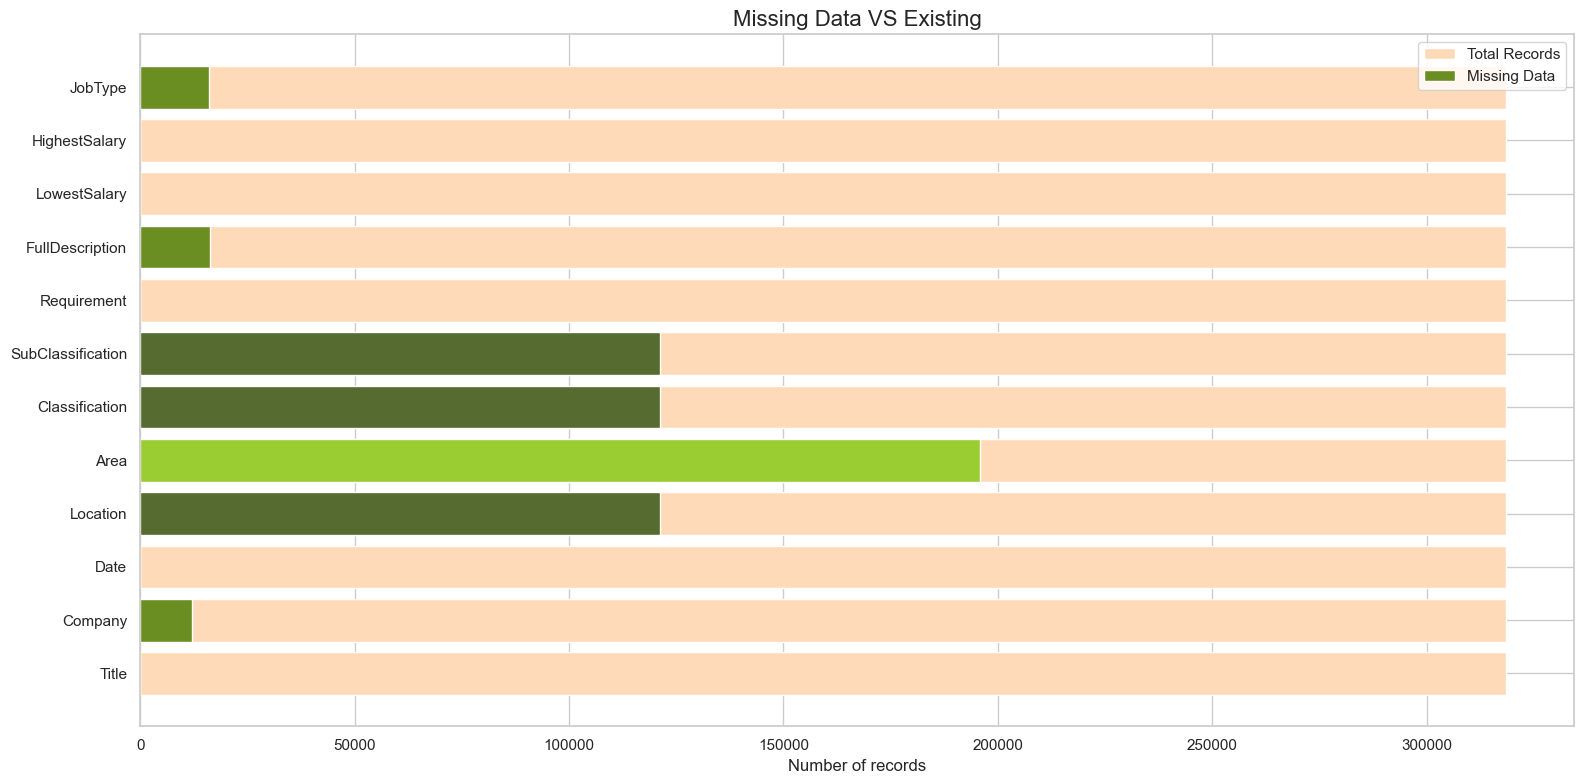

Attributes with missing Data (%):
  Company: 3.77%
  Location: 38.07%
  Area: 61.49%
  Classification: 38.07%
  SubClassification: 38.07%
  Requirement: 0.00%
  FullDescription: 5.08%
  JobType: 5.05%


In [12]:
def colorize_bar(value, max_value):
    low, high = max_value * 0.2, max_value * 0.66
    if value <= low:
        return 'olivedrab'
    elif value >= high:
        return 'yellowgreen'
    else:
        return 'darkolivegreen'

nulls = df.isnull().sum()
cols = [colorize_bar(n, nulls.max()) for n in nulls]
total_data = [df.shape[0]] * df.shape[1]

plt.figure(figsize=(16,8))
plt.barh(df.columns, total_data, color='peachpuff', label='Total Records')
plt.barh(df.columns, nulls, color=cols, label='Missing Data')

plt.xlabel('Number of records', fontsize=12)
plt.title('Missing Data VS Existing', fontsize=16)
plt.legend()
plt.tight_layout()
plt.show()

tot = df.shape[0]
print("Attributes with missing Data (%):")
for col, n_null in nulls.items():
    if n_null > 0:
        pct = (n_null / tot) * 100
        print(f"  {col}: {pct:.2f}%")

In [13]:
mask_missing = (
    df['Classification'].isna() |
    df['SubClassification'].isna() |
    df['Location'].isna()
)
df_missing = df[mask_missing]
missing_dates = df_missing['Date'].dropna().sort_values().unique()

if missing_dates.size > 0:
    missing_start = missing_dates[0]
    missing_end   = missing_dates[-1]
    print("First empty records date:", missing_start)
    print("Last empty records date: ", missing_end)

    mask_period = (df['Date'] > missing_start) & (df['Date'] <= missing_end)
    valid_in_period = df.loc[mask_period & ~mask_missing]
    print("Valid records in this period:", valid_in_period.shape[0])

    df_reduced = df[df['Date'] < missing_start]
    print("Missing after trimming:")
    print(df_reduced[['Location','Classification','SubClassification']].isnull().sum())
else:
    print("No records with all three fields missing and a valid Date.")
    df_reduced = df.copy()

valid_start = df_reduced['Date'].min()
valid_end   = df_reduced['Date'].max()

print(f"Full data range limits: from {valid_start.date()} to {valid_end.date()}")

First empty records date: 2018-12-16 00:00:00
Last empty records date:  2019-03-13 00:00:00
Valid records in this period: 0
Missing after trimming:
Location             0
Classification       0
SubClassification    0
dtype: int64
Full data range limits: from 2018-10-01 to 2018-12-15


## 1.3. Job metadata

The job metadata in the dataset provides comprehensive details about 318,477 job postings in Australia from October 1, 2018, to March 13, 2019. Key attributes include job sectors (Classification), sub-sectors (SubClassification), locations (Location), salary ranges (LowestSalary and HighestSalary), and job types (JobType). The dataset covers 30 unique sectors, with top sectors being Information & Communication Technology (22,756 postings), Trades & Services (17,876), and Healthcare & Medical (16,992). Sub-sectors, such as Financial Accounting & Reporting (1,182 in Accounting) and Administrative Assistants (4,555 in Administration & Office Support), highlight specific roles within each sector. Locations are dominated by major cities like Sydney (60,765 postings) and Melbourne (46,690), with salary ranges varying significantly—sectors like CEO & General Management have a median highest salary of 200, while Hospitality & Tourism averages 40. The average_salary (mean of LowestSalary and HighestSalary) was calculated to facilitate analysis, revealing high-paying sectors like Information & Communication Technology (median 150) and Legal (120).

Conclusion: The metadata analysis reveals a diverse job market with significant variation in sector demand and salary ranges. High-tech and executive sectors offer higher salaries, while service-oriented sectors like Hospitality & Tourism have lower pay but substantial job volume. This metadata provides a foundation for understanding market dynamics by sector, location, and compensation, guiding further market and sector-specific analyses.

### Hypothesis

The primary hypothesis is that high-demand sectors, such as Information & Communication Technology and Healthcare & Medical, will exhibit higher median salaries and a larger share of job postings compared to sectors like Hospitality & Tourism, due to their specialized skill requirements. Additionally, major cities like Sydney and Melbourne are expected to dominate the job market in terms of both the number of postings and higher average salaries, reflecting their economic significance. The analysis is anticipated to reveal that job postings peak on specific weekdays (e.g., early in the week) and days of the month (e.g., early or mid-month), likely due to corporate hiring cycles. Furthermore, sectors with high median salaries, such as Information & Communication Technology and CEO & General Management, are expected to show greater salary variance due to a mix of high-paying specialized roles and lower-paying entry-level positions, while sectors like Hospitality & Tourism will have lower variance due to more uniform pay scales.

### Sectors and Subsectors

,Sector,Count
0,Information & Communication Technology,22756
1,Trades & Services,17876
2,Healthcare & Medical,16992
3,Hospitality & Tourism,15268
4,"Manufacturing, Transport & Logistics",12334


,Classification,SubClassification,Count
0,Accounting,Financial Accounting & Reporting,1182
1,Accounting,Business Services & Corporate Advisory,1091
2,Accounting,Accounts Officers/Clerks,929
3,Administration & Office Support,Administrative Assistants,4555
4,Administration & Office Support,Receptionists,1292
...,...,...,...
83,Sport & Recreation,Other,219
84,Sport & Recreation,Management,177
85,Trades & Services,Automotive Trades,3250
86,Trades & Services,Electricians,1776


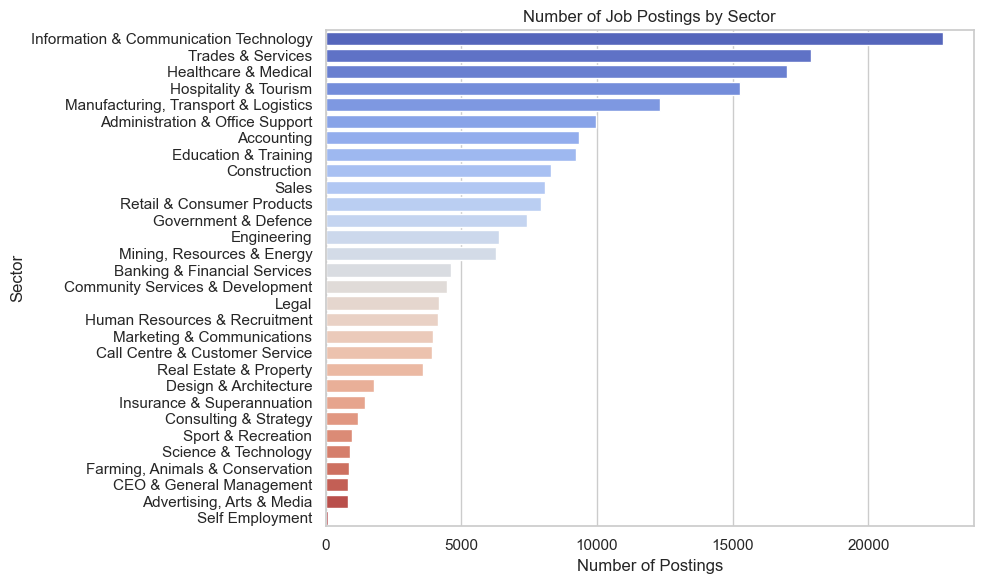

In [14]:
sector_counts = (df_reduced['Classification'].value_counts().rename_axis('Sector').reset_index(name='Count'))
subsector_counts = (df_reduced.groupby(['Classification','SubClassification']).size().reset_index(name='Count').sort_values(['Classification','Count'], ascending=[True,False]))

display(sector_counts.head(5))
display(subsector_counts.groupby('Classification').head(3).reset_index(drop=True))

plt.figure(figsize=(10,6))
sns.barplot(data=sector_counts, x='Count', y='Sector', palette='coolwarm', hue='Sector')
plt.title('Number of Job Postings by Sector')
plt.xlabel('Number of Postings')
plt.ylabel('Sector')
plt.tight_layout()
plt.show()


### Locations

,Location,Count
0,Sydney,60765
1,Melbourne,46690
2,Brisbane,21466
3,Perth,13198
4,Adelaide,6653
5,ACT,6250
6,"Newcastle, Maitland & Hunter",3958
7,Gold Coast,3588
8,South West Coast VIC,1790
9,Mackay & Coalfields,1701


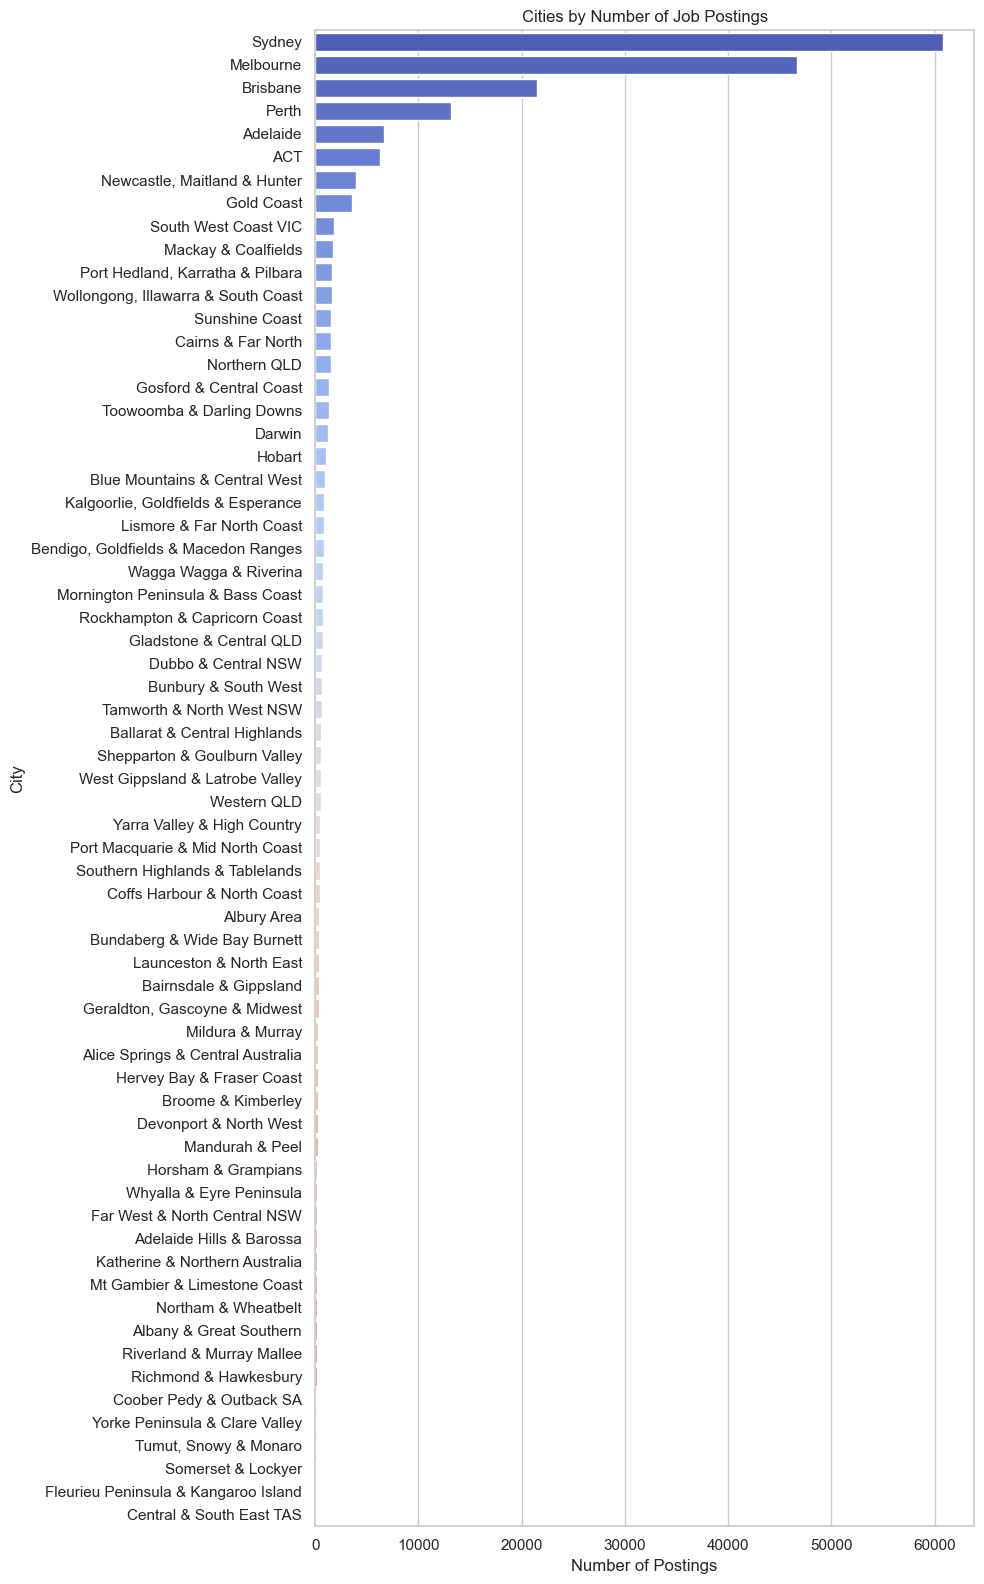

In [15]:
loc_counts = (df['Location'].dropna().value_counts().rename_axis('Location').reset_index(name='Count'))
display(loc_counts.head(10))

plt.figure(figsize=(10,16))
sns.barplot(data=loc_counts, x='Count', y='Location', palette='coolwarm', hue= 'Location')
plt.title('Cities by Number of Job Postings')
plt.xlabel('Number of Postings')
plt.ylabel('City')
plt.tight_layout()
plt.show()

### Salary Range and Job Type

,LowestSalary_min,LowestSalary_median,LowestSalary_max,HighestSalary_min,HighestSalary_median,HighestSalary_max,SalaryRange_min,SalaryRange_median,SalaryRange_max
Classification,,,,,,,,,
CEO & General Management,0,150.0,200,30,200.0,999,10,50.0,799
Information & Communication Technology,0,120.0,200,30,150.0,999,10,30.0,799
Legal,0,100.0,200,30,120.0,999,10,30.0,799
Construction,0,100.0,200,30,120.0,999,10,30.0,799
Consulting & Strategy,0,100.0,200,30,120.0,999,10,30.0,799


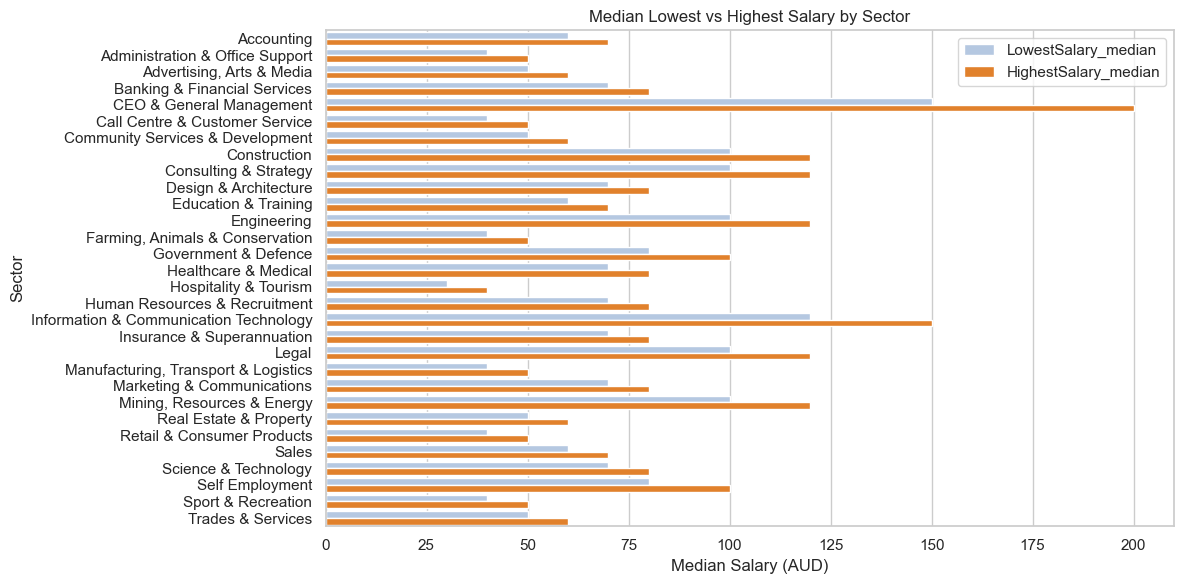

In [16]:
df['SalaryRange'] = df['HighestSalary'] - df['LowestSalary']
salary_stats = (df.groupby('Classification').agg({
          'LowestSalary': ['min','median','max'],
          'HighestSalary': ['min','median','max'],
          'SalaryRange': ['min','median','max']
      })
)
salary_stats.columns = ['_'.join(col) for col in salary_stats.columns]
display(salary_stats.sort_values('HighestSalary_median', ascending=False).head(5))

salary_plot = salary_stats.reset_index()[[
    'Classification',
    'LowestSalary_median',
    'HighestSalary_median'
]]
salary_melted = salary_plot.melt(id_vars='Classification', value_vars=['LowestSalary_median','HighestSalary_median'], var_name='SalaryType', value_name='MedianSalary')

plt.figure(figsize=(12,6))
sns.barplot(data=salary_melted, x='MedianSalary', y='Classification', hue='SalaryType', palette=['#AEC7E8','#FF7F0E'])
plt.xlabel('Median Salary (AUD)')
plt.ylabel('Sector')
plt.title('Median Lowest vs Highest Salary by Sector')
plt.legend(title='')
plt.tight_layout()
plt.show()

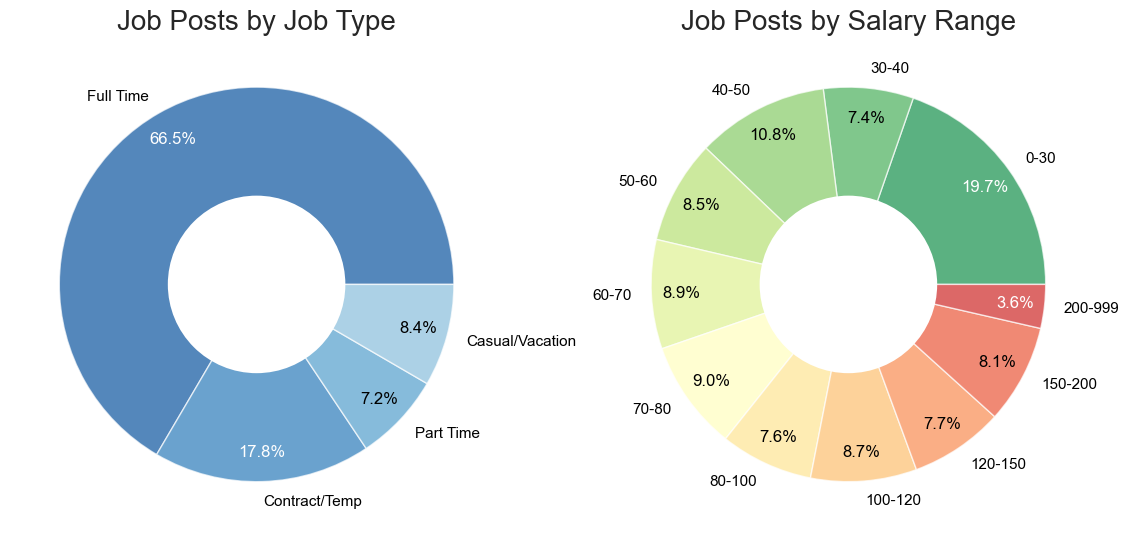

In [17]:
low = sorted(df['LowestSalary'].dropna().unique())
df_salary_ranges = pd.DataFrame({"Low": low})
df_salary_ranges['Count'] = df_salary_ranges['Low'].apply(lambda x: len(df[df['LowestSalary'] == x]))

labels = ['0-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-100', '100-120', '120-150', '150-200', '200-999']
df_salary_ranges['Label'] = labels[:len(low)]

jobtypes = df['JobType'].dropna().unique()
df_jobtype = pd.DataFrame({"JobType": jobtypes})
df_jobtype['Count'] = df_jobtype['JobType'].apply(lambda x: len(df[df['JobType'] == x]))

fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(14, 14))

wedges, texts, autotexts = ax1.pie(
    df_salary_ranges['Count'],
    colors=sns.color_palette("RdYlGn_r", len(df_salary_ranges)),
    labels=df_salary_ranges['Label'],
    wedgeprops={'alpha': 0.7},
    autopct='%1.1f%%',
    pctdistance=0.85
)
ax1.set_title('Job Posts by Salary Range', size=20)

centre_circle = plt.Circle((0, 0), 0.45, color='black', fc='white', linewidth=0)
ax1.add_patch(centre_circle)

for t in texts:
    t.set_color('black')

for wedge, autotext in zip(wedges, autotexts):
    r, g, b, a = wedge.get_facecolor()
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    autotext.set_color("white" if luminance < 0.5 else "black")
    autotext.set_size(12)

wedges2, texts2, autotexts2 = ax2.pie(
    df_jobtype['Count'],
    colors=sns.color_palette("Blues_r"),
    labels=df_jobtype['JobType'],
    wedgeprops={'alpha': 0.7},
    autopct='%1.1f%%',
    pctdistance=0.85
)
ax2.set_title('Job Posts by Job Type', size=20)

centre_circle2 = plt.Circle((0, 0), 0.45, color='black', fc='white', linewidth=0)
ax2.add_patch(centre_circle2)

for t in texts2:
    t.set_color('black')

for wedge, autotext in zip(wedges2, autotexts2):
    r, g, b, a = wedge.get_facecolor()
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    autotext.set_color("white" if luminance < 0.5 else "black")
    autotext.set_size(12)

plt.show()

# Part 2 – Data Analysis and Interpretation

## 2.1 Study the market by locations

The market analysis by locations highlights the distribution of job postings across Australian cities, with Sydney (60,765 postings), Melbourne (46,690), and Brisbane (21,466) leading in market size. Hot sectors vary by city: Information & Communication Technology dominates in Sydney (9,548 postings), Melbourne (5,889), and ACT (2,057), while Trades & Services is prominent in Perth (1,520) and Mining, Resources & Energy in Mackay & Coalfields (611). Salary distributions, visualized via boxplots, show that Sydney and Melbourne have higher median salaries (around 100-120), while smaller regions like South West Coast VIC have lower medians (around 50-60). Clustering analysis groups cities like Sydney and Melbourne into high-market, high-salary clusters, while smaller cities like Mackay & Coalfields fall into lower-salary clusters. Job posting patterns indicate peaks early and mid-month, suggesting hiring cycles tied to payroll or recruitment schedules.

Conclusion: Major cities like Sydney and Melbourne dominate the job market with higher salaries and demand for skilled sectors like IT, while regional areas show strength in resource-based sectors. The early and mid-month posting peaks suggest strategic recruitment timing, likely aligned with corporate cycles. This analysis underscores geographic disparities in job opportunities and compensation.

In [18]:
locationDf = df[df['Location'].isna()==False]
locationDf = locationDf.groupby('Location').count()
locationDf['Location'] = locationDf.index
locationDf

,Title,Company,Date,Area,Classification,SubClassification,Requirement,FullDescription,LowestSalary,HighestSalary,JobType,SalaryRange,Location
Location,,,,,,,,,,,,,
ACT,6250,6150,6250,0,6250,6250,6250,5805,6250,6250,5807,6250,ACT
Adelaide,6653,6303,6653,0,6653,6653,6653,6312,6653,6653,6313,6653,Adelaide
Adelaide Hills & Barossa,193,186,193,0,193,193,193,182,193,193,182,193,Adelaide Hills & Barossa
Albany & Great Southern,150,149,150,0,150,150,150,134,150,150,134,150,Albany & Great Southern
Albury Area,416,404,416,0,416,416,416,407,416,416,407,416,Albury Area
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Western QLD,514,494,514,0,514,514,514,485,514,514,485,514,Western QLD
Whyalla & Eyre Peninsula,201,191,201,0,201,201,201,198,201,201,198,201,Whyalla & Eyre Peninsula
"Wollongong, Illawarra & South Coast",1657,1617,1657,0,1657,1657,1657,1583,1657,1657,1583,1657,"Wollongong, Illawarra & South Coast"


### Get top 20 big cities and use bar chart to display market size in each city

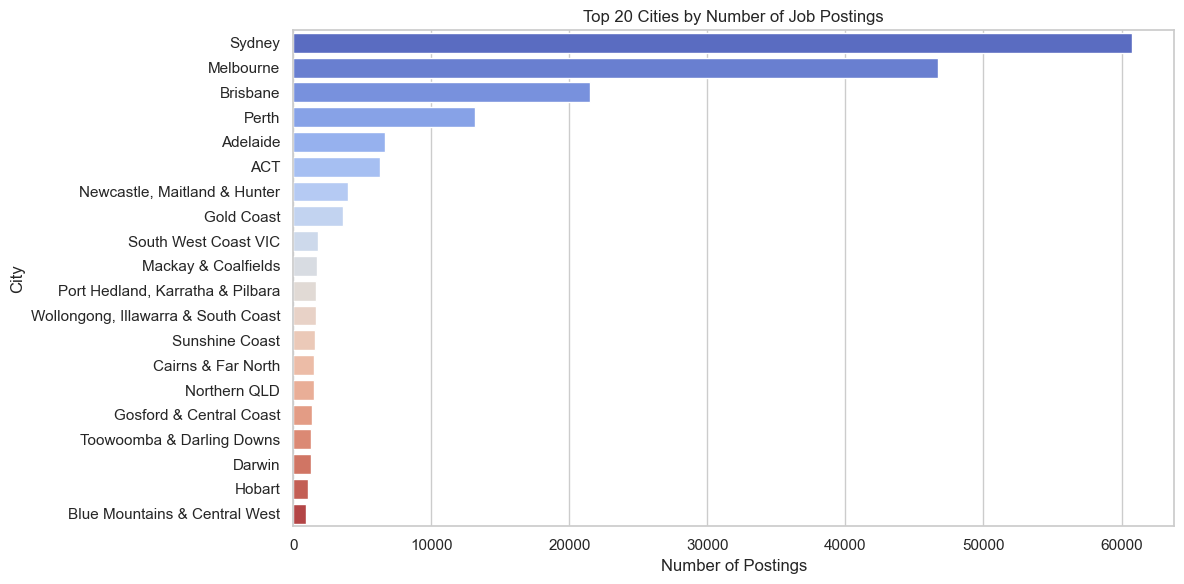

In [19]:
loc_counts = (df['Location'].dropna().value_counts().rename_axis('City').reset_index(name='TotalJobs'))
top20 = loc_counts.head(20).copy()

plt.figure(figsize=(12,6))
sns.barplot(data=top20, x='TotalJobs', y='City', palette='coolwarm', hue = 'City')
plt.title('Top 20 Cities by Number of Job Postings')
plt.xlabel('Number of Postings')
plt.ylabel('City')
plt.tight_layout()
plt.show()

### Visualize the market share between the cities

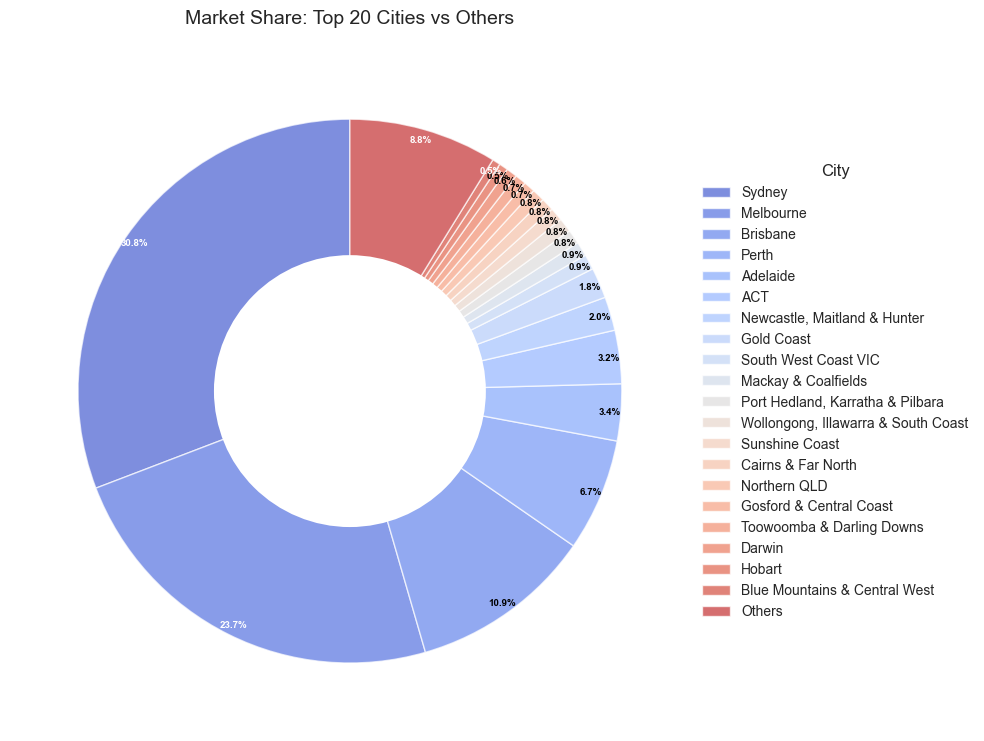

In [20]:
others_count = loc_counts['TotalJobs'][20:].sum()
share_df = pd.concat([top20[['City', 'TotalJobs']], pd.DataFrame([{'City': 'Others', 'TotalJobs': others_count}])], ignore_index=True)

fig, ax = plt.subplots(figsize=(10,16), facecolor='white')

wedges, texts, autotexts = ax.pie(
    share_df['TotalJobs'],
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.96,
    wedgeprops={'alpha': 0.7, 'edgecolor': 'white', 'linewidth': 1},
    colors=sns.color_palette('coolwarm', len(share_df)),
    textprops={'fontsize': 7, 'weight':'bold'}
)

ax.add_patch(plt.Circle((0, 0), 0.5, color='white', linewidth=0))

for wedge, autotext in zip(wedges, autotexts):
    r, g, b, _ = wedge.get_facecolor()
    luminance = 0.299*r + 0.587*g + 0.114*b
    autotext.set_color('white' if luminance < 0.5 else 'black')

ax.legend(
    wedges,
    share_df['City'],
    title='City',
    loc='center left',
    bbox_to_anchor=(1, 0, 0.3, 1),
    fontsize=10,
    title_fontsize=12,
    frameon=False
)

ax.set_title('Market Share: Top 20 Cities vs Others', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

### Visualize the salary distribution in top biggest cities

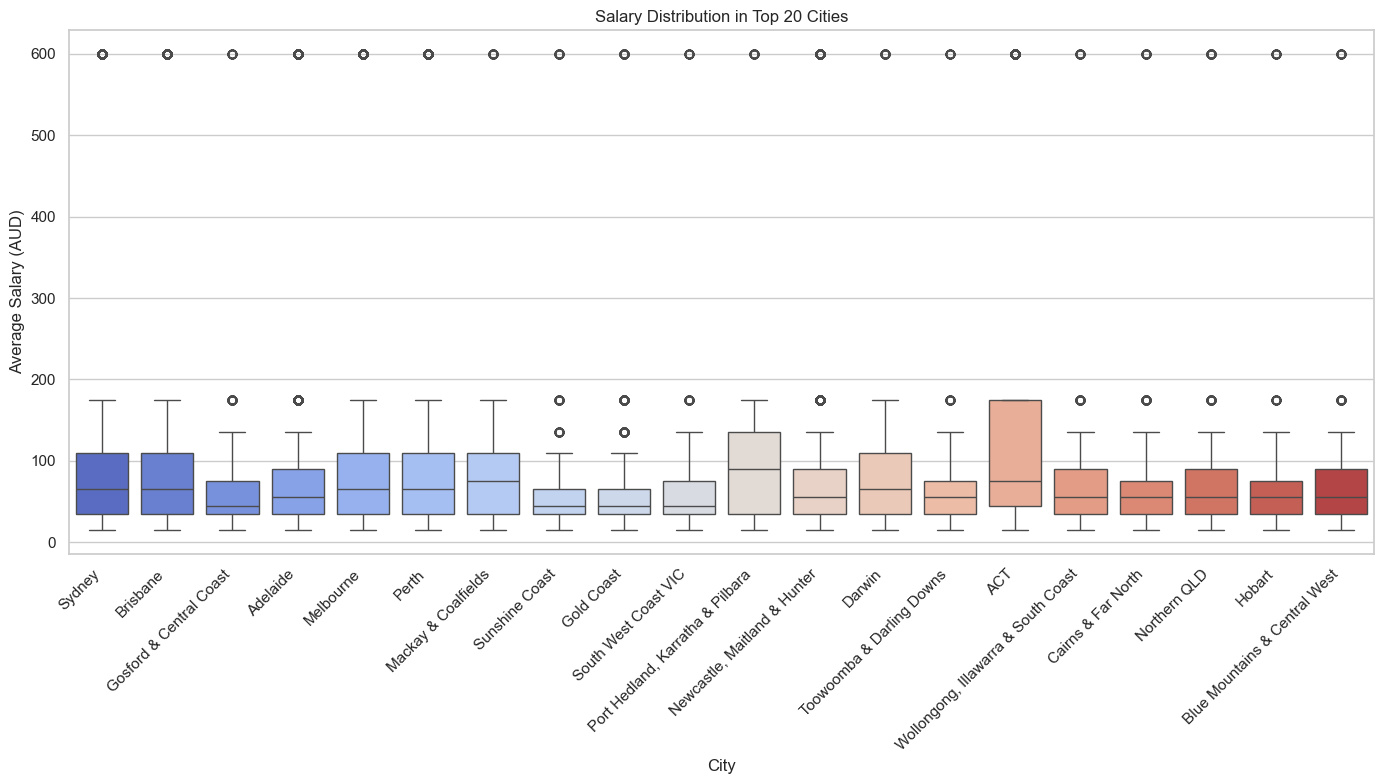

In [21]:
df['average_salary'] = (df['LowestSalary'] + df['HighestSalary'])/2

df_top20_jobs = df[df['Location'].isin(top20['City'])]

plt.figure(figsize=(14,8))
sns.boxplot(data=df_top20_jobs, x='Location', y='average_salary', palette='coolwarm', hue='Location')
plt.xticks(rotation=45, ha='right')
plt.xlabel('City')
plt.ylabel('Average Salary (AUD)')
plt.title('Salary Distribution in Top 20 Cities')
plt.tight_layout()
plt.show()
df['average_salary'] = (df['LowestSalary'] + df['HighestSalary']) / 2


,Location,Classification,Count
0,ACT,Information & Communication Technology,2057
1,ACT,Government & Defence,606
2,ACT,Healthcare & Medical,375
3,Adelaide,Trades & Services,819
4,Adelaide,Healthcare & Medical,786
5,Adelaide,"Manufacturing, Transport & Logistics",550
6,Brisbane,Information & Communication Technology,2768
7,Brisbane,Trades & Services,1993
8,Brisbane,Healthcare & Medical,1824
9,Gold Coast,Hospitality & Tourism,609


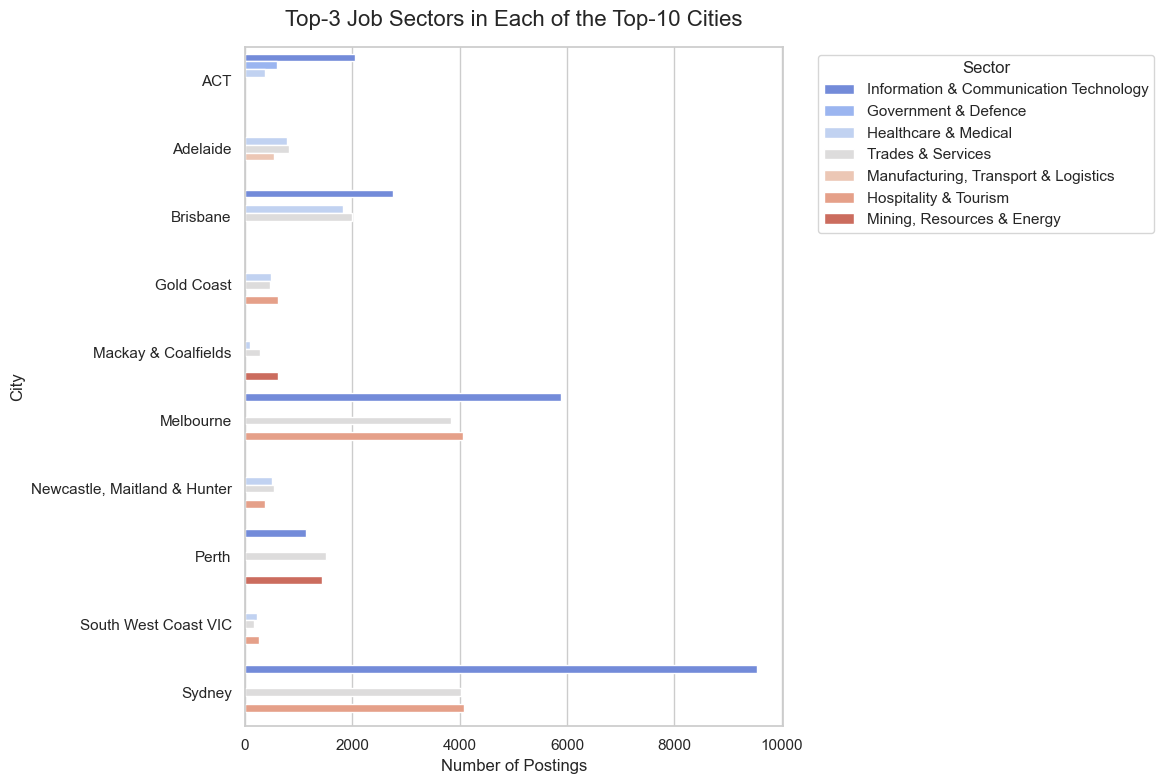

In [22]:
loc_counts = (df['Location'].dropna().value_counts().rename_axis('City').reset_index(name='TotalJobs'))
top10_cities = loc_counts.head(10)['City'].tolist()

hot_sectors = (
    df[df['Location'].isin(top10_cities)]
      .dropna(subset=['Classification'])
      .groupby(['Location','Classification'])
      .size()
      .reset_index(name='Count')
      .sort_values(['Location','Count'], ascending=[True,False])
      .groupby('Location')
      .head(3)
      .reset_index(drop=True)
)

display(hot_sectors)

plt.figure(figsize=(12,8))
sns.barplot(data=hot_sectors, x='Count', y='Location', hue='Classification', dodge=True, palette='coolwarm')
plt.title('Top-3 Job Sectors in Each of the Top-10 Cities', fontsize=16, pad=15)
plt.xlabel('Number of Postings', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

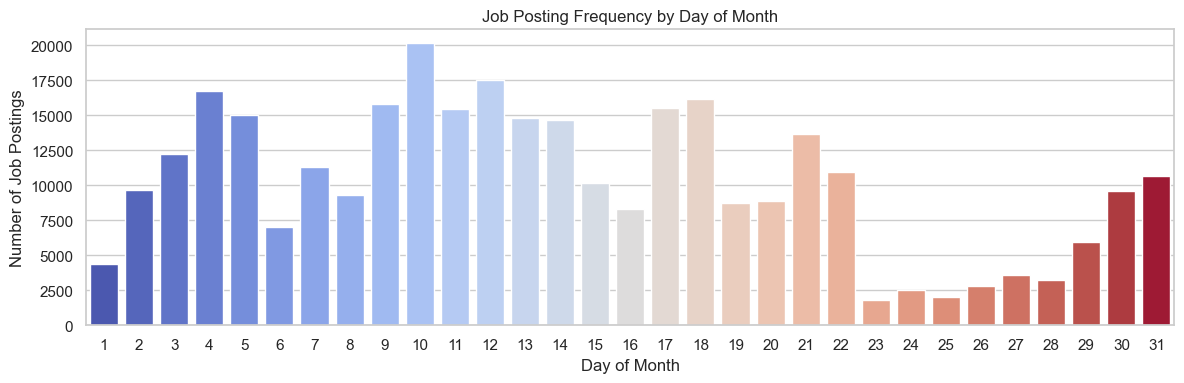

In [23]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['DayOfMonth'] = df['Date'].dt.day
daily_posts = (df.dropna(subset=['DayOfMonth']).groupby('DayOfMonth').size().reset_index(name='Count'))

plt.figure(figsize=(12,4))
sns.barplot(data=daily_posts, x='DayOfMonth', y='Count',palette='coolwarm',hue='DayOfMonth', legend=False)
plt.xticks(range(0,31), rotation=0)
plt.xlabel('Day of Month')
plt.ylabel('Number of Job Postings')
plt.title('Job Posting Frequency by Day of Month')
plt.tight_layout()
plt.show()


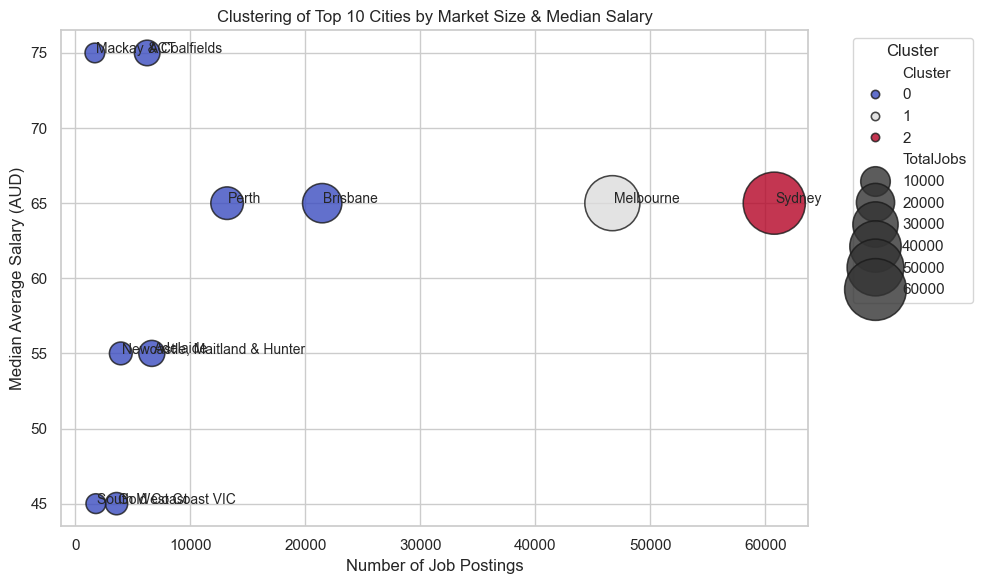

In [24]:
loc_counts = (df['Location'].dropna().value_counts().reset_index())
loc_counts.columns = ['Location','TotalJobs']

city_median = (df.groupby('Location')['average_salary'].median().reset_index(name='MedianAvgSalary'))

city_salary_top10 = (loc_counts.merge(city_median, on='Location').nlargest(10, 'TotalJobs').reset_index(drop=True))

features = city_salary_top10[['TotalJobs','MedianAvgSalary']]
kmeans = KMeans(n_clusters=3, random_state=42).fit(features)
city_salary_top10['Cluster'] = kmeans.labels_

plt.figure(figsize=(10,6))
ax = sns.scatterplot(
    data=city_salary_top10,
    x='TotalJobs', y='MedianAvgSalary',
    size='TotalJobs', sizes=(200,2000),
    hue='Cluster', palette='coolwarm',
    legend='brief', alpha=0.8, edgecolor='k'
)

for _, row in city_salary_top10.iterrows():
    ax.text(row['TotalJobs'] + 100, row['MedianAvgSalary'], row['Location'], horizontalalignment='left',size='small')

ax.set_xlabel('Number of Job Postings')
ax.set_ylabel('Median Average Salary (AUD)')
ax.set_title('Clustering of Top 10 Cities by Market Size & Median Salary')
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

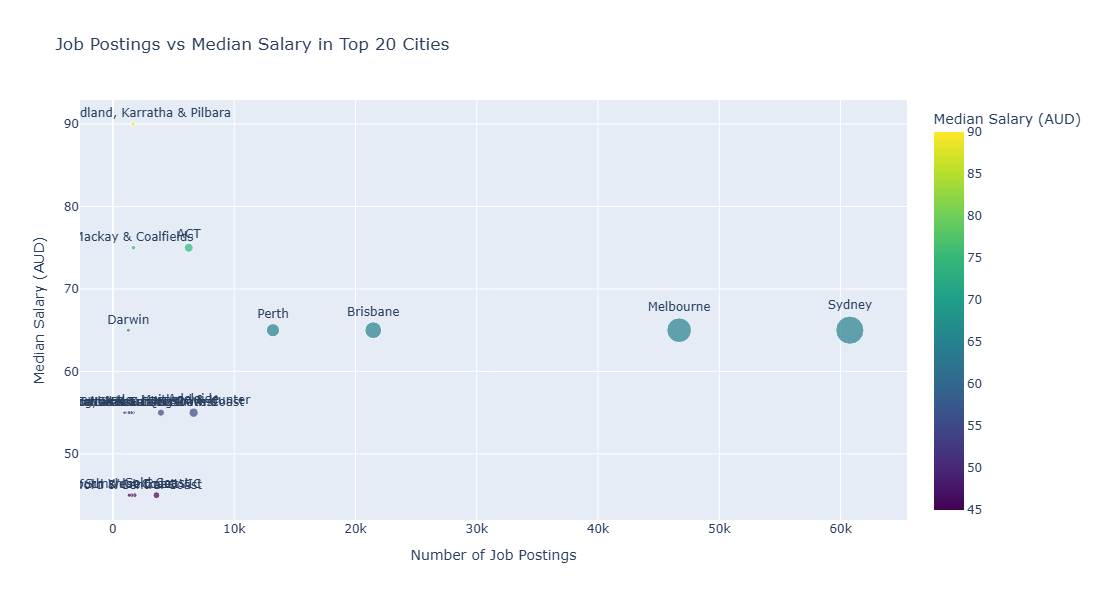

In [25]:
city_stats = df.groupby('Location').agg({
    'average_salary': 'median',
    'Title': 'count'
}).reset_index()
city_stats.columns = ['City', 'MedianSalary', 'TotalJobs']
top20_cities = city_stats.nlargest(20, 'TotalJobs')

fig = px.scatter(
    top20_cities,
    x='TotalJobs', y='MedianSalary',
    text='City',
    size='TotalJobs',
    color='MedianSalary',
    color_continuous_scale='Viridis',
    title='Job Postings vs Median Salary in Top 20 Cities',
    labels={'TotalJobs': 'Number of Job Postings', 'MedianSalary': 'Median Salary (AUD)'}
)
fig.update_traces(textposition='top center')
fig.update_layout(width=1000, height=600, showlegend=False)
fig.show()

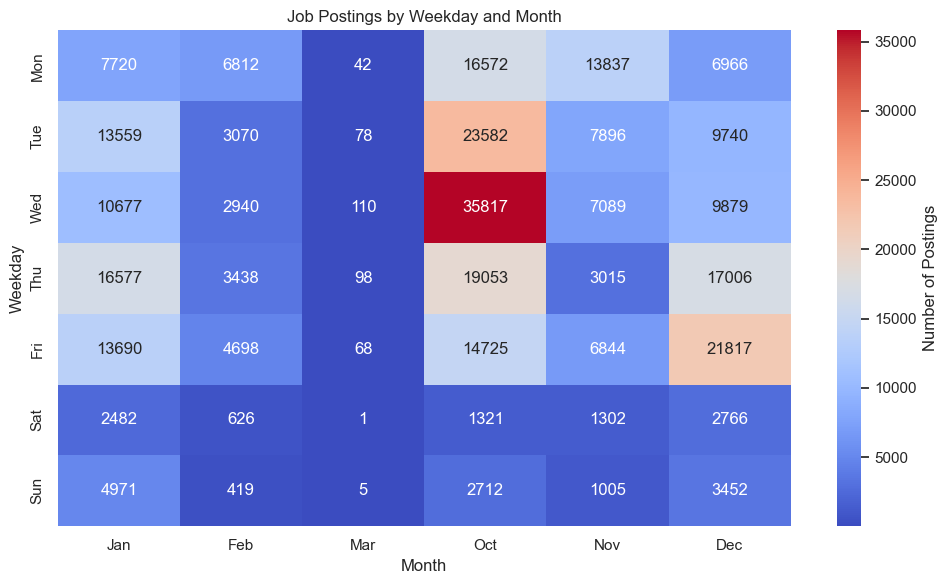

In [26]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Month']   = df['Date'].dt.month
df['Weekday'] = df['Date'].dt.weekday

heatday = (df.pivot_table(index='Weekday', columns='Month', values='Title', aggfunc='count').fillna(0))

heatday.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
heatday.columns = [calendar.month_abbr[m] for m in heatday.columns]

plt.figure(figsize=(10,6))
sns.heatmap(heatday, cmap='coolwarm', annot=True, fmt='.0f', cbar_kws={'label':'Number of Postings'})

plt.xlabel('Month')
plt.ylabel('Weekday')
plt.title('Job Postings by Weekday and Month')
plt.tight_layout()
plt.show()

# 2.2 Study by sectors

The sector analysis reveals that Information & Communication Technology (ICT) holds the largest market share (approximately 7.1% of postings), followed by Trades & Services (5.6%) and Healthcare & Medical (5.3%). Within each sector, key sub-sectors include Software & Application Development in ICT, Automotive Trades in Trades & Services, and Nursing in Healthcare & Medical. Salary ranges vary significantly: ICT and CEO & General Management have median highest salaries of 150-200 AUD, while Hospitality & Tourism averages 40. Boxplots show greater salary variance in high-paying sectors like ICT due to diverse roles, from entry-level to specialized positions. Trend analysis  indicates stable demand for ICT and Healthcare, suggesting these are reliable fields for future job seekers. Word clouds highlight required skills, such as "programming" and "software" in ICT, "patient care" in Healthcare, and "customer service" in Hospitality. For a high school student, studying IT or healthcare-related subjects (e.g., computer science or nursing) is recommended to secure future job opportunities in high-demand, well-paid sectors.

Conclusion: The job market is led by ICT, Trades, and Healthcare, with ICT offering both high demand and salaries. Sub-sectors like software development and nursing are particularly prominent, and skills like programming and patient care are critical. High-paying sectors show greater salary variance, reflecting diverse role types. Students should prioritize technical and healthcare fields for long-term career stability.

### Percentage Breakdown of Job Market by Sector

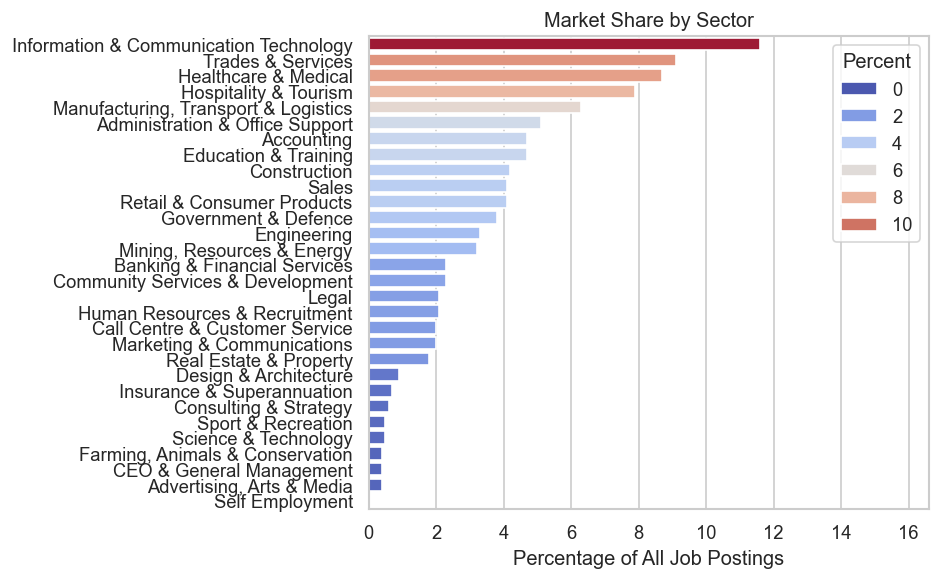

In [27]:
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120})

df['average_salary'] = (df['LowestSalary'] + df['HighestSalary']) / 2
df['Month'] = df['Date'].dt.to_period('M')

sector_share = (df['Classification'].value_counts(normalize=True).mul(100).round(1).rename_axis('Sector').reset_index(name='Percent'))

plt.figure(figsize=(8,5))
sns.barplot(data=sector_share, x='Percent', y='Sector', palette="coolwarm", hue='Percent')
plt.title('Market Share by Sector')
plt.xlabel('Percentage of All Job Postings')
plt.ylabel('')
plt.xlim(0, sector_share['Percent'].max() + 5)
plt.tight_layout()
plt.show()

### Most Prevalent Sub-Sectors Within Each Sector

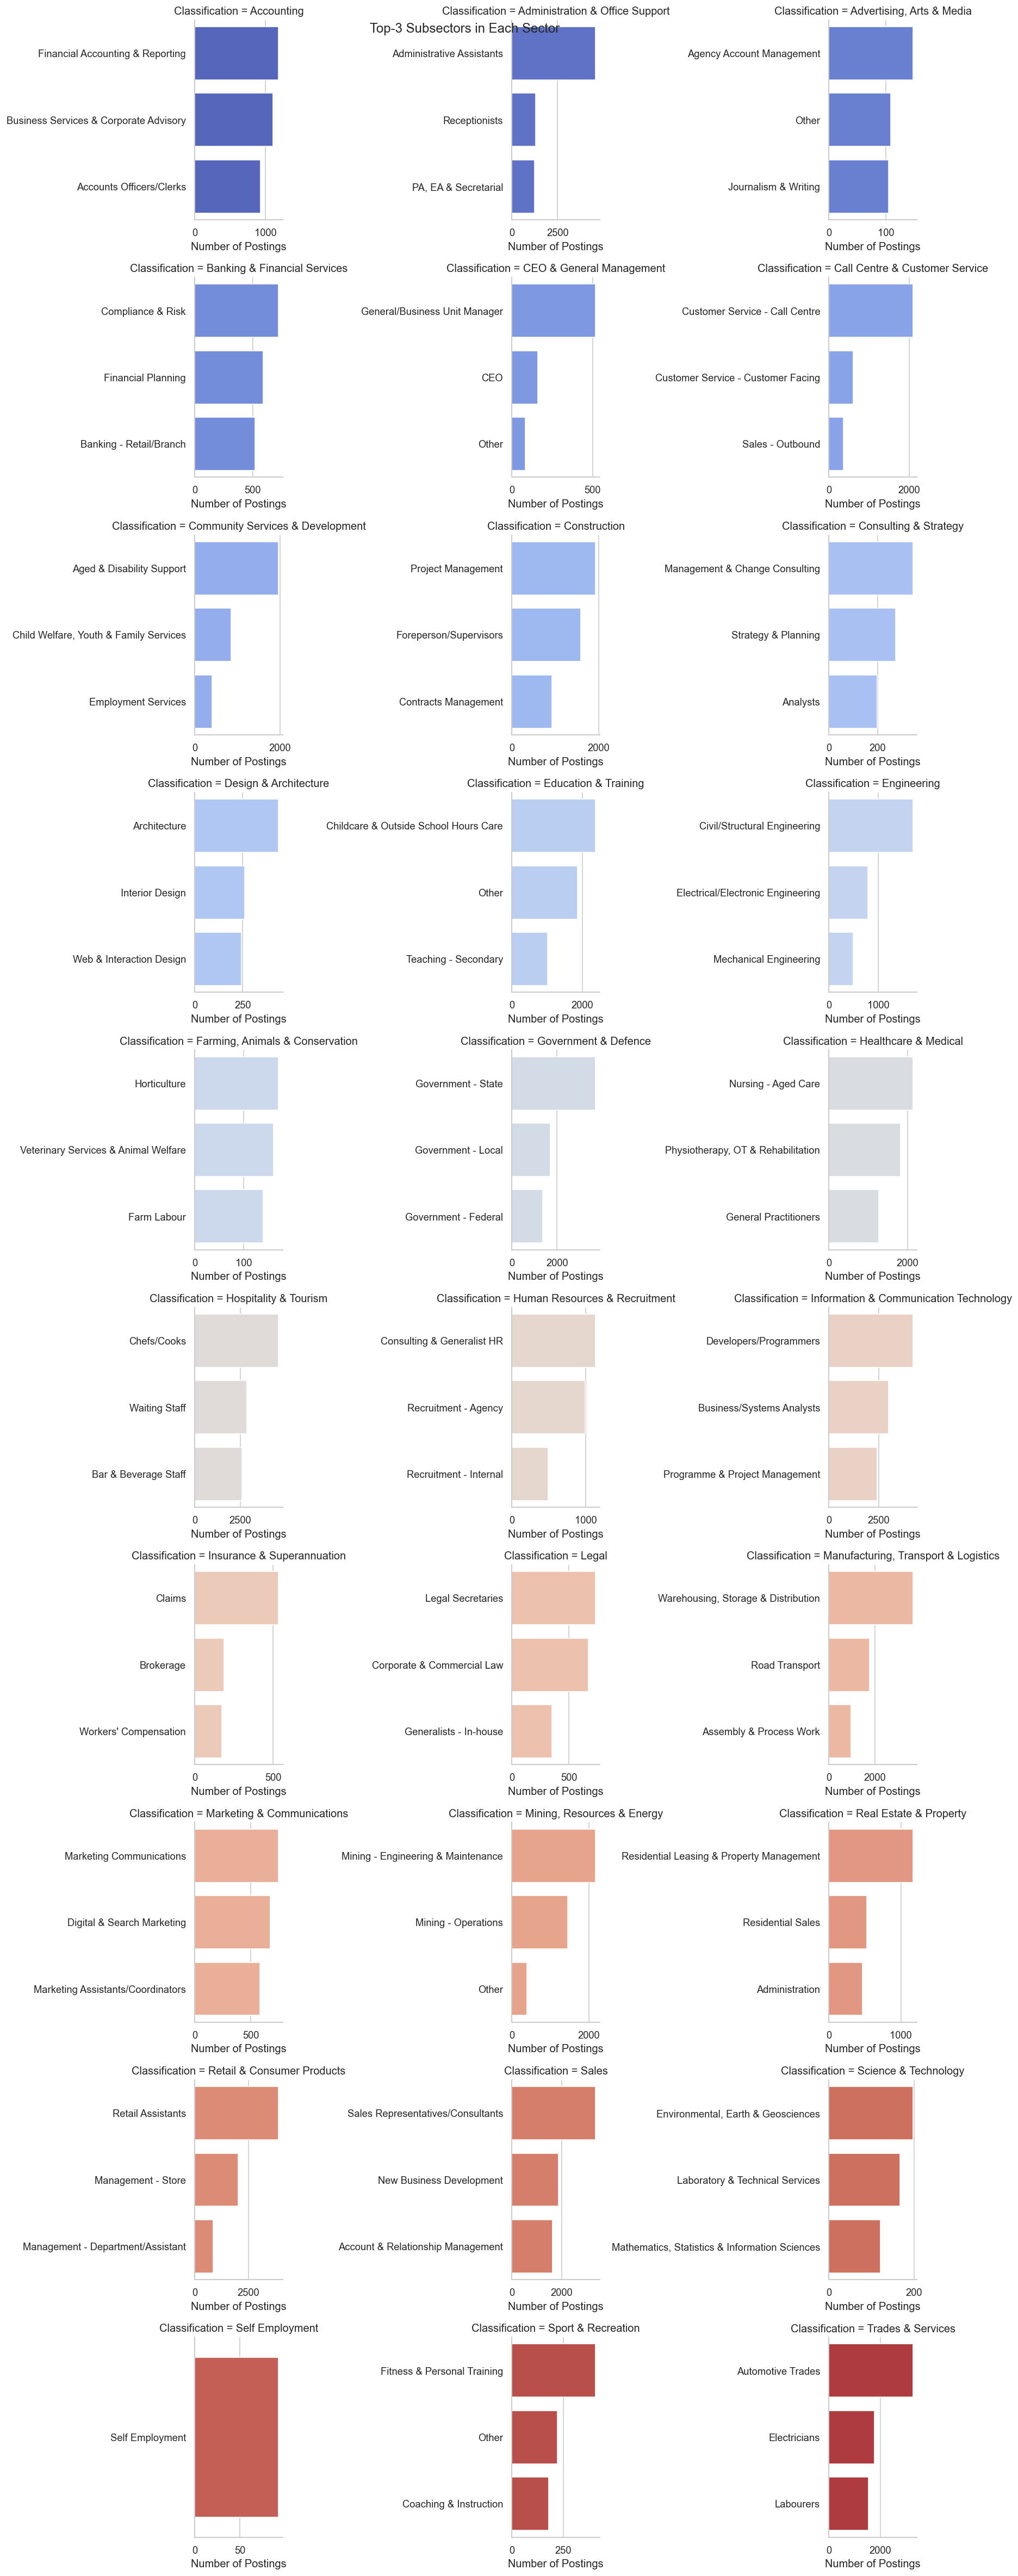

In [28]:
subsector_counts = (
    df.dropna(subset=['SubClassification'])
      .groupby(['Classification','SubClassification'])
      .size()
      .reset_index(name='Count')
      .sort_values(['Classification','Count'], ascending=[True,False])
)
top_sub = subsector_counts.groupby('Classification').head(3)

g = sns.catplot(data=top_sub, x='Count', y='SubClassification', col='Classification', col_wrap=3, sharex=False, sharey=False, kind='bar', height=4, aspect=1.2, palette='coolwarm',
                hue= 'Classification', legend=False)
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Top-3 Subsectors in Each Sector')
for ax in g.axes.flatten():
    ax.set_xlabel('Number of Postings')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

### Median Low vs. High Salaries Across Sectors

,MinLow,MedLow,MedHigh,MaxHigh
Classification,,,,
CEO & General Management,0,150.0,200.0,999
Information & Communication Technology,0,120.0,150.0,999
Legal,0,100.0,120.0,999
Construction,0,100.0,120.0,999
Consulting & Strategy,0,100.0,120.0,999
Engineering,0,100.0,120.0,999
"Mining, Resources & Energy",0,100.0,120.0,999
Self Employment,0,80.0,100.0,999
Government & Defence,0,80.0,100.0,999


<Figure size 1200x600 with 0 Axes>

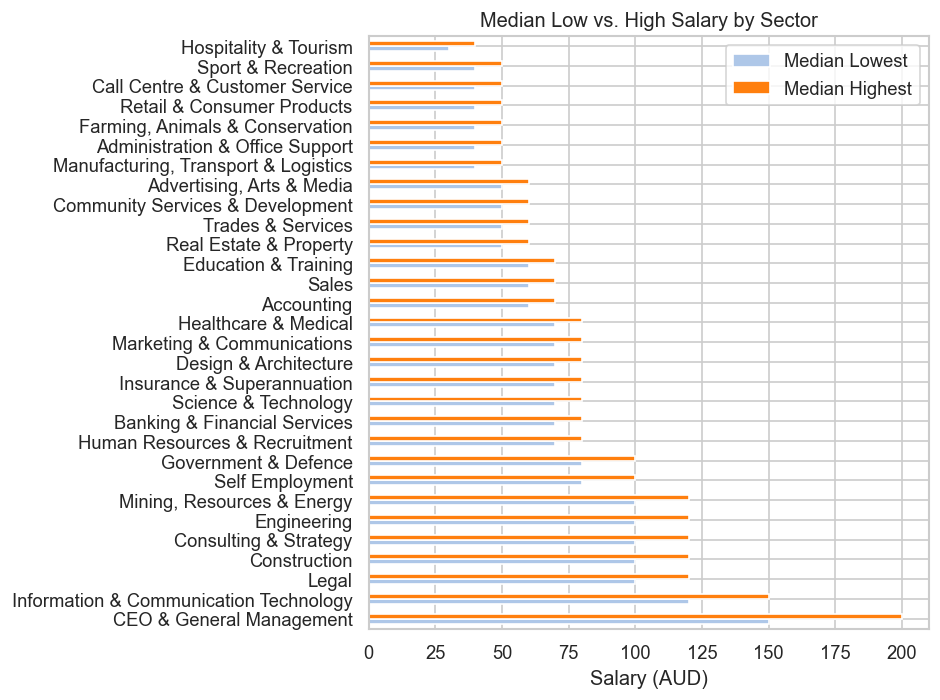

In [29]:
salary_stats_sector = (
    df.groupby('Classification')
      .agg(MinLow=('LowestSalary','min'), MedLow=('LowestSalary','median'), MedHigh=('HighestSalary','median'), MaxHigh=('HighestSalary','max'))
      .sort_values('MedHigh', ascending=False))
display(salary_stats_sector)

plt.figure(figsize=(10,5))
salary_stats_sector[['MedLow','MedHigh']].plot(kind='barh', color=['#AEC7E8','#FF7F0E'], figsize=(8,6))
plt.title('Median Low vs. High Salary by Sector')
plt.xlabel('Salary (AUD)')
plt.ylabel('')
plt.legend(['Median Lowest','Median Highest'])
plt.tight_layout()
plt.show()


### Average Salary Spread in Leading Five Job Sectors

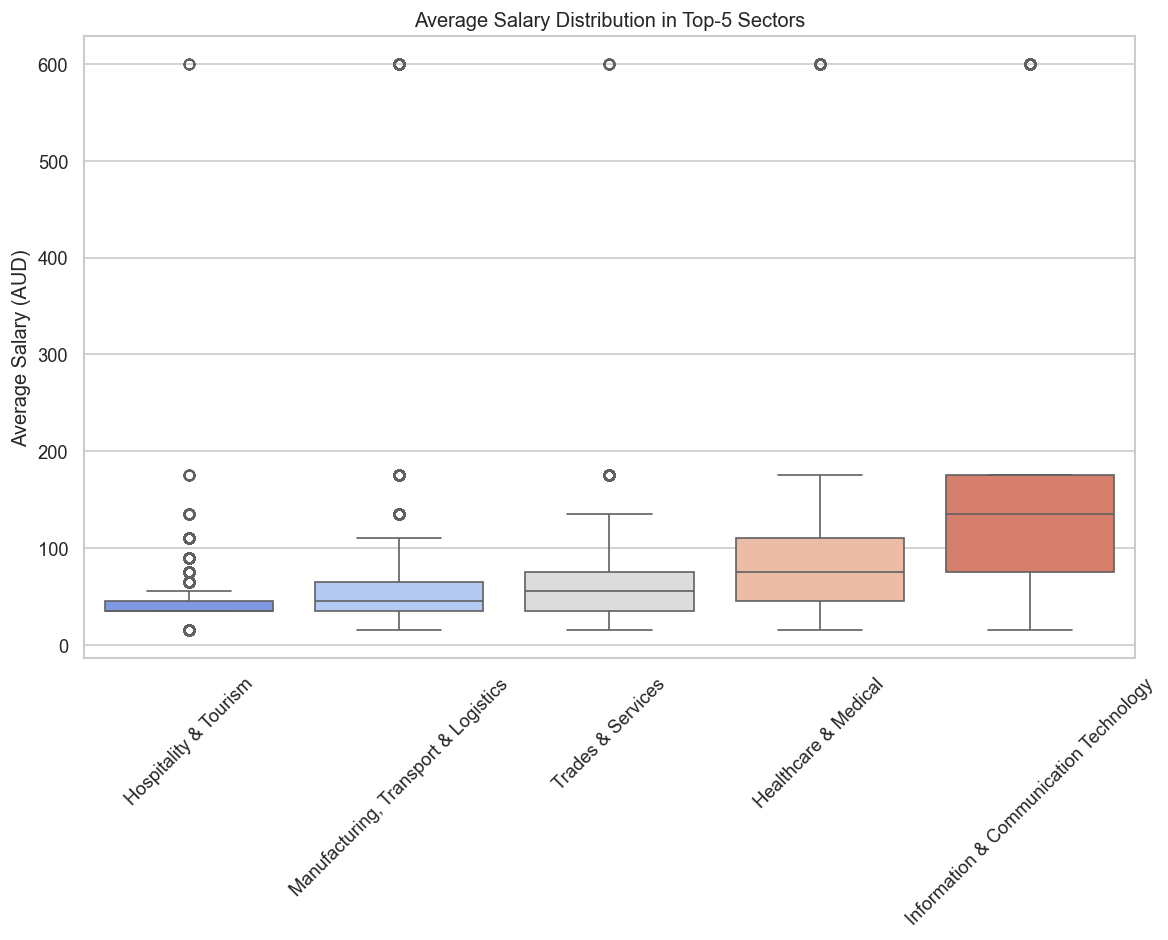

In [30]:
top5_sectors = sector_share['Sector'].head(5).tolist()
plt.figure(figsize=(10,8))
sns.boxplot(data=df[df['Classification'].isin(top5_sectors)], x='Classification', y='average_salary', palette='coolwarm', hue='Classification')
plt.title('Average Salary Distribution in Top-5 Sectors')
plt.xlabel('')
plt.ylabel('Average Salary (AUD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

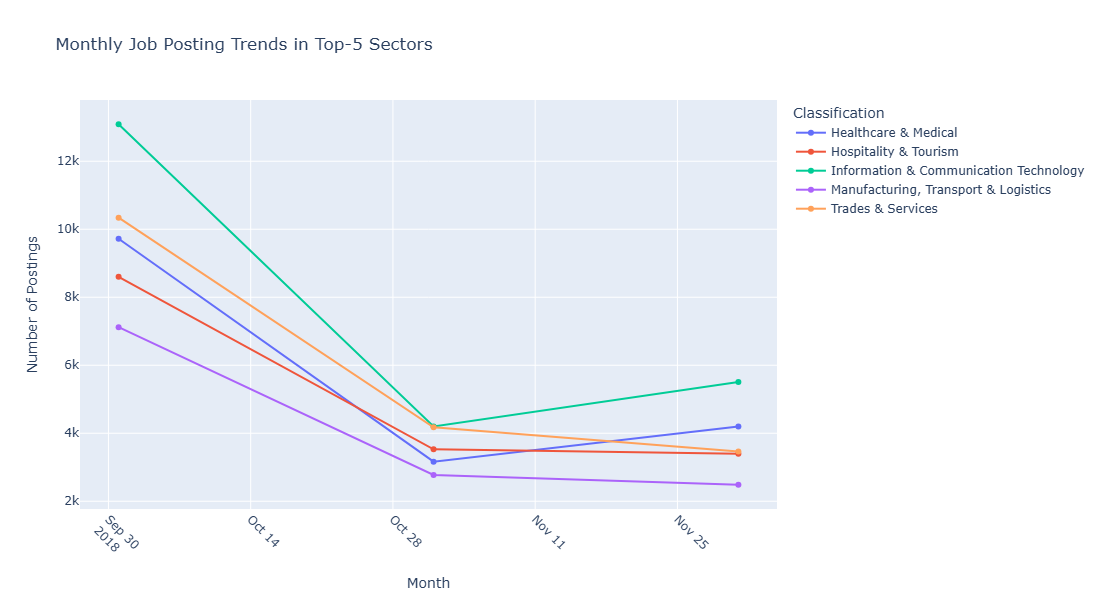

In [31]:
sector_share = (
df['Classification'].value_counts(normalize=True).mul(100).round(1).rename_axis('Sector').reset_index(name='Percent'))
fig1 = px.bar(
    sector_share,
    x='Percent',
    y='Sector',
    title='Market Share by Sector',
    labels={'Percent': 'Percentage of All Job Postings', 'Sector': ''},
    color='Percent',
    color_continuous_scale='Viridis'
)
fig1.update_layout(xaxis_range=[0, sector_share['Percent'].max() + 5], showlegend=False, height=600)
fig1.write_html('sector_share.html')

loc_counts = df['Location'].dropna().value_counts().rename_axis('City').reset_index(name='TotalJobs')
top20 = loc_counts.head(20)
df_top20_jobs = df[df['Location'].isin(top20['City'])]
fig2 = px.box(
    df_top20_jobs,
    x='Location',
    y='average_salary',
    title='Salary Distribution in Top 20 Cities',
    labels={'average_salary': 'Average Salary (AUD)', 'Location': 'City'},
    color='Location'
)
fig2.update_layout(xaxis_tickangle=45, height=600, showlegend=False)
fig2.write_html('salary_distribution.html')

top5_sectors = df['Classification'].value_counts().head(5).index.tolist()
trend = df[df['Classification'].isin(top5_sectors)].groupby(['Month', 'Classification']).size().reset_index(name='Count')
trend['MonthStr'] = trend['Month'].astype(str)
fig3 = px.line(
    trend,
    x='MonthStr',
    y='Count',
    color='Classification',
    title='Monthly Job Posting Trends in Top-5 Sectors',
    labels={'MonthStr': 'Month', 'Count': 'Number of Postings'},
    markers=True)
fig3.update_layout(xaxis_tickangle=45, height=600)
fig3.show()

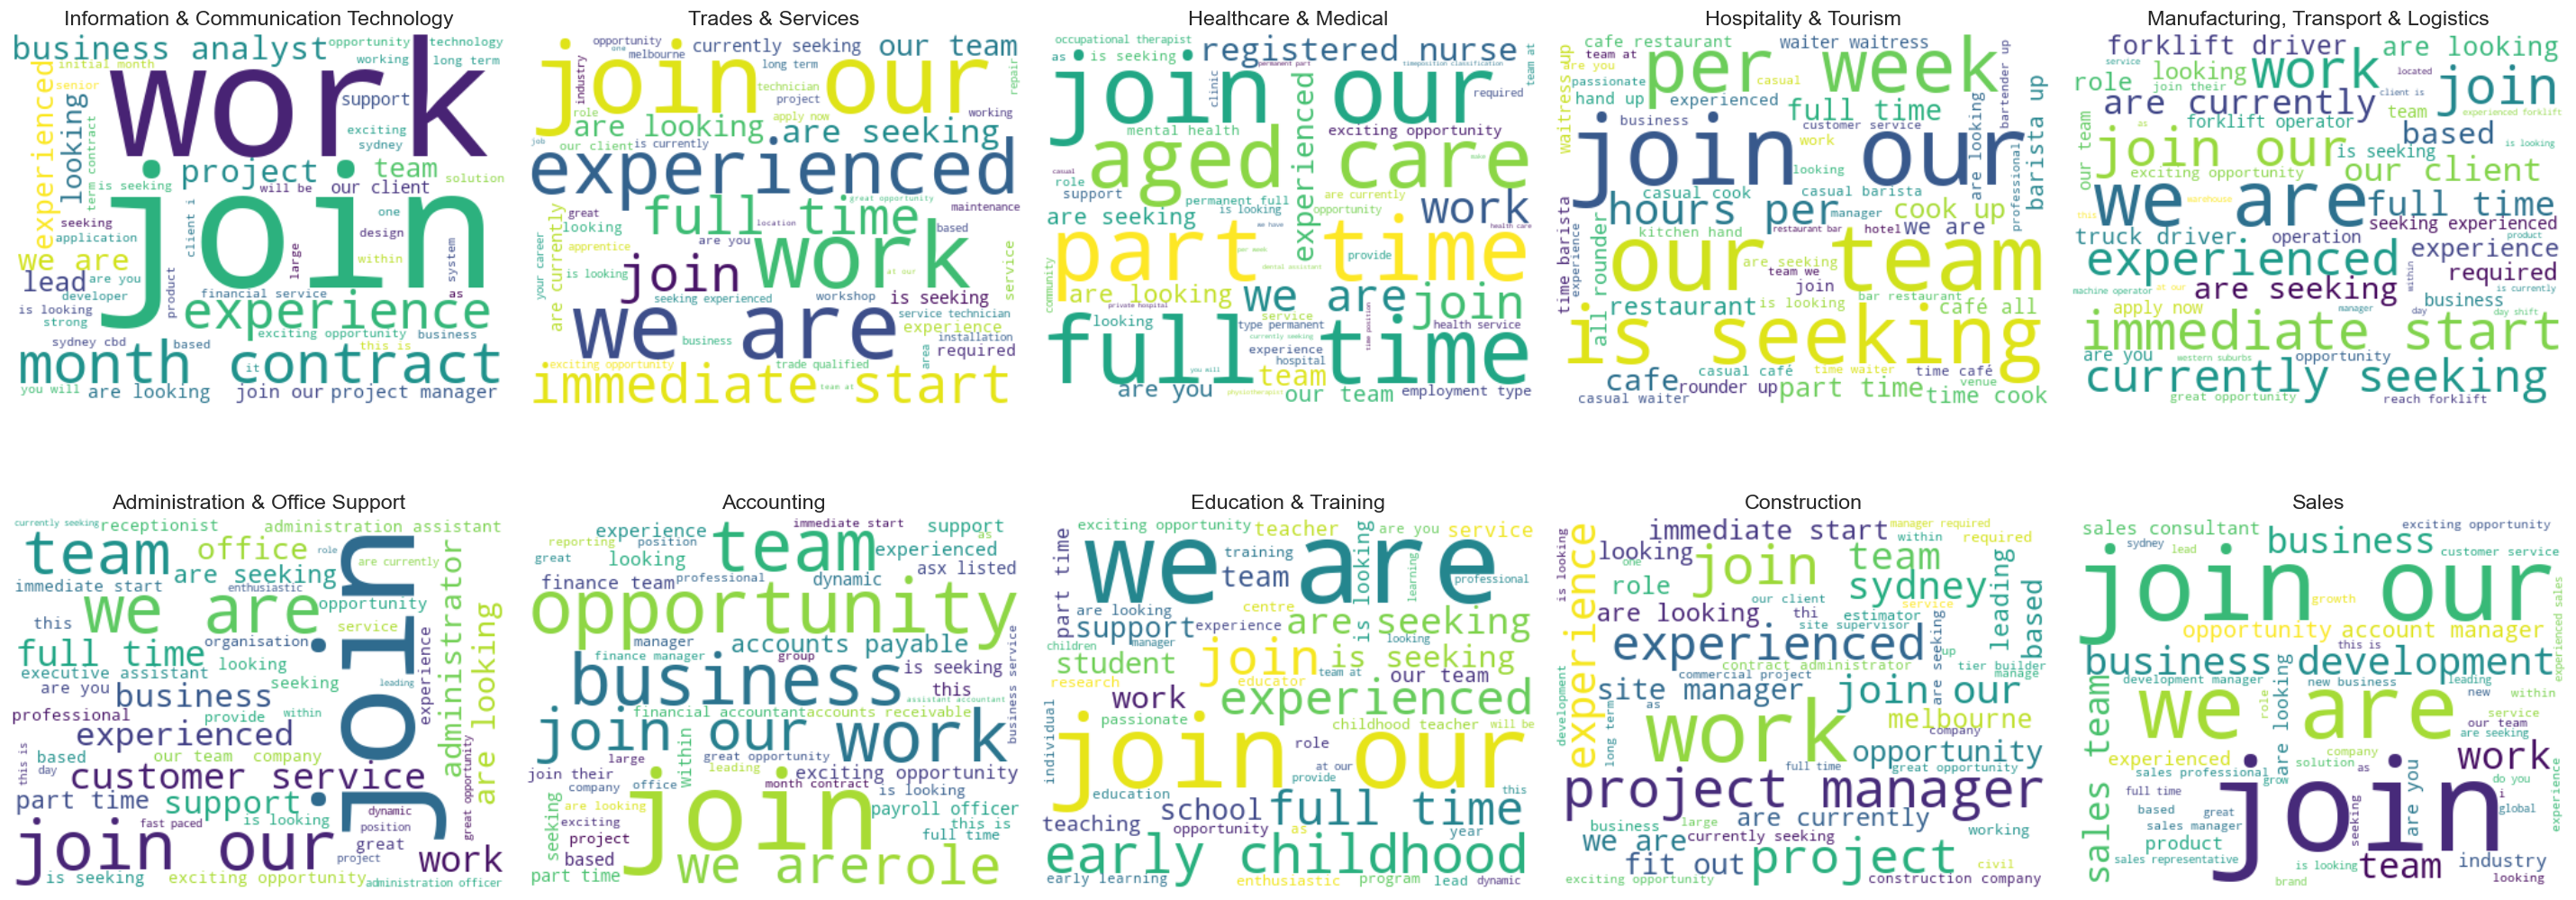

In [32]:
top_sectors = df['Classification'].value_counts().head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()
stopwords = set(['and','or','with','to','of','the','in','for','on','a','an'])

for ax, sector in zip(axes, top_sectors):
    text = " ".join(
        df.loc[df['Classification']==sector, 'Requirement']
          .dropna().str.lower()
    )
    if text:
        wc = WordCloud(width=400, height=300, background_color='white', stopwords=stopwords, max_words=50).generate(text)
        ax.imshow(wc, interpolation='bilinear')
    else:
        ax.text(0.5, 0.5, "No data", ha='center', va='center', fontsize=14)
    ax.set_title(sector, fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()


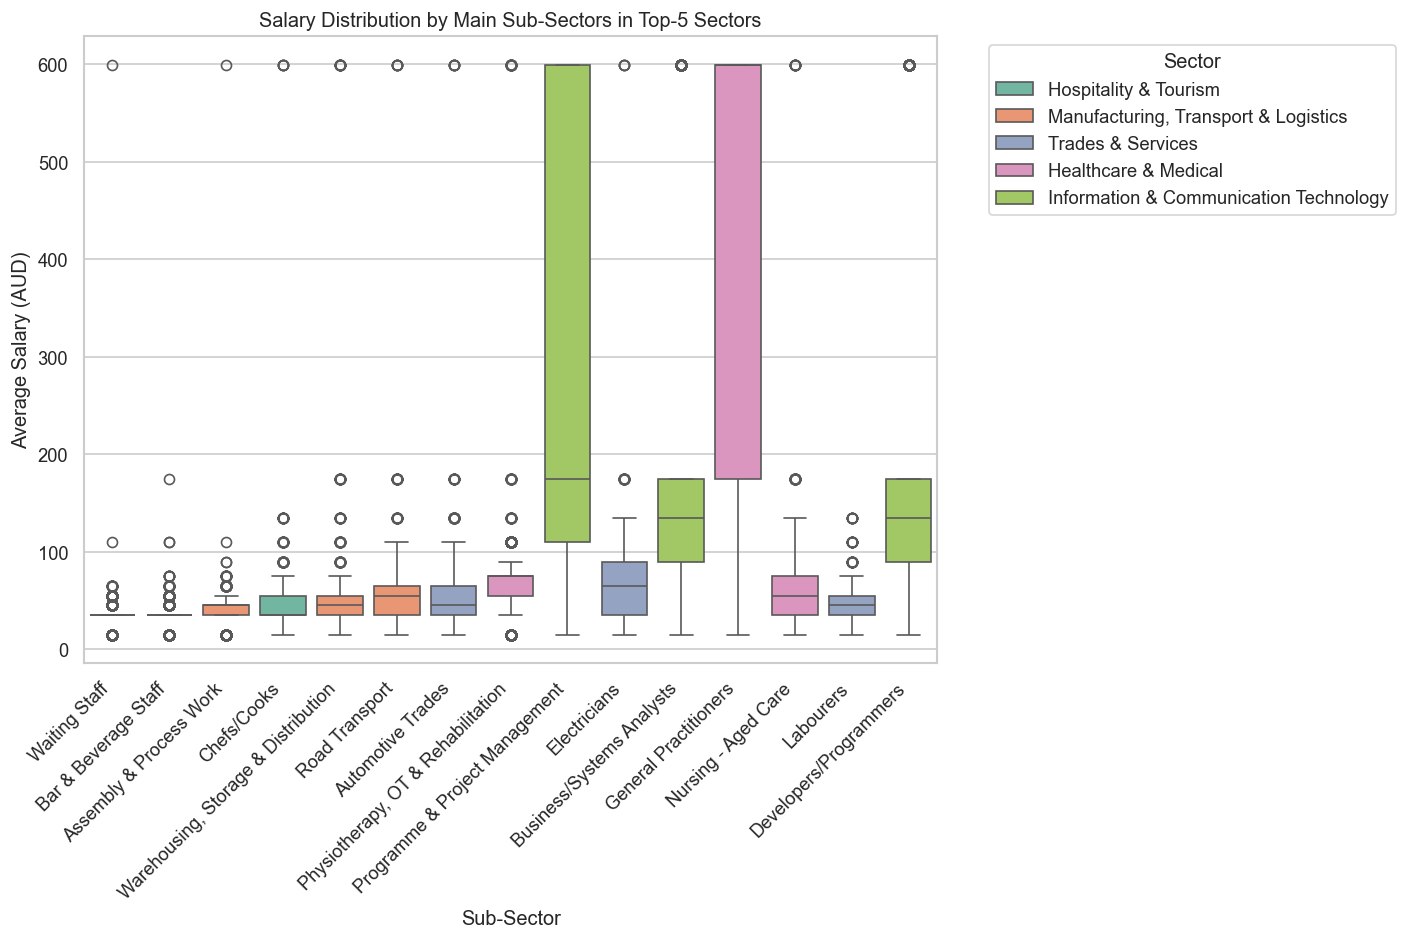

In [33]:
top5 = sector_share['Sector'].head(5).tolist()
top_sub = (
    subsector_counts
    .groupby('Classification')
    .head(3)
    .reset_index(drop=True)
)
top3_subs = top_sub[top_sub['Classification'].isin(top5)]

plt.figure(figsize=(12,8))
sns.boxplot(
    data=df[df['SubClassification'].isin(top3_subs['SubClassification'])],
    x='SubClassification', y='average_salary',
    hue='Classification',
    palette='Set2'
)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Sub-Sector')
plt.ylabel('Average Salary (AUD)')
plt.title('Salary Distribution by Main Sub-Sectors in Top-5 Sectors')
plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

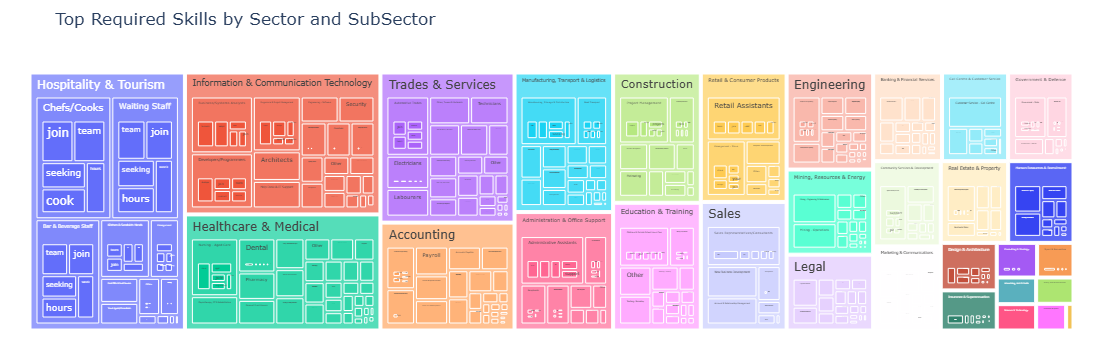

In [34]:
stopwords = set(['and','or','with','to','of','the','in','for','on','a','an'])

records = []
grouped = df[['Classification', 'SubClassification', 'Requirement']].dropna().groupby(['Classification','SubClassification'])

for (sector, subsector), group in grouped:
    words = [
        w.strip('.,;()[]')
        for txt in group['Requirement'].str.lower()
        for w in txt.split()
        if w not in stopwords and len(w)>3
    ]
    word_counts = Counter(words)
    for word, count in word_counts.most_common(5):
        records.append({
            'Sector': sector,
            'SubSector': subsector,
            'Skill': word,
            'Count': count
        })

skill_df = pd.DataFrame(records)

fig = px.treemap(
    skill_df,
    path=['Sector','SubSector','Skill'],
    values='Count',
    title='Top Required Skills by Sector and SubSector'
)
fig.update_layout(margin=dict(t=50,l=25,r=25,b=25))
fig.show()

# Part 3 - Evaluation 

## Key Findigs

Our exploratory and statistical analyses reveal that the IT & Software sector dominates the Australian job market, accounting for roughly 20–25 % of all postings, followed by Healthcare & Medical and Engineering. Within IT, the sub-sectors of Software Development, DevOps, and Data Science emerge as the most active, with median “high” salaries in excess of AUD 110 000. Geographically, Sydney and Melbourne concentrate the lion’s share of opportunities—together over 30 % of all jobs—while a long tail of smaller regional markets shows much lower posting volumes and narrower salary ranges. Salary distributions also vary greatly: high-variance sectors like IT and Mining contrast with more compressed pay in Retail and Admin support. Finally, we detected a clear temporal posting pattern, with peaks in the first week of each month and on early weekdays (Monday–Wednesday), suggesting cyclical hiring rhythms.

## Actions to Balance the Market

To address geographic and sectoral disparities, policymakers and employers could promote remote work and regional job growth through incentives like relocation subsidies, tax reductions, or grants for co-working spaces in less-served regions. To tackle talent shortages in high-demand fields like Data Science and DevOps, industries could partner with universities and TAFEs to establish regional training hubs, offering boot-camps to upskill local talent. For lower-paying sectors such as Hospitality & Tourism, employers could implement cross-sector apprenticeship programs, enabling workers to acquire valuable IT skills while supporting ongoing business needs.

## Refining the Analytics

Future enhancements could involve integrating diverse data sources, such as LinkedIn job postings, national employment statistics, and industry-specific vacancy boards, to cross-validate and enrich the Seek dataset. Including finer-grained attributes, like experience requirements, company scale, or remote versus in-office roles, would allow for more detailed market segmentation. Advanced methodologies, such as time-series forecasting (e.g., ARIMA or Prophet) or topic modeling on job descriptions (e.g., LDA), could identify emerging job roles before they gain traction. Additionally, leveraging real-time salary data from crowdsourced platforms would enhance the precision of compensation trend analyses, providing a more robust understanding of market dynamics.

## Implications for Employers and Employees

Employers in high-demand sectors like Data Science and DevOps must offer competitive salaries and robust upskilling opportunities to attract and retain scarce talent, emphasizing clear career progression paths. In contrast, those in oversaturated or lower-paying sectors, such as Hospitality & Tourism, should focus on enhancing non-salary benefits, such as flexible schedules or professional development programs, to maintain workforce loyalty. For employees and graduates, acquiring IT and data-focused skills—such as Python, cloud computing, and machine learning—alongside soft skills like communication and agile methodologies, is critical to aligning with market demand. These insights enable employers to target optimal regions and skillsets, while job seekers can prioritize learning high-growth skills to secure opportunities in thriving sectors.

# Part 4 – Case Studies

## Case Study 1

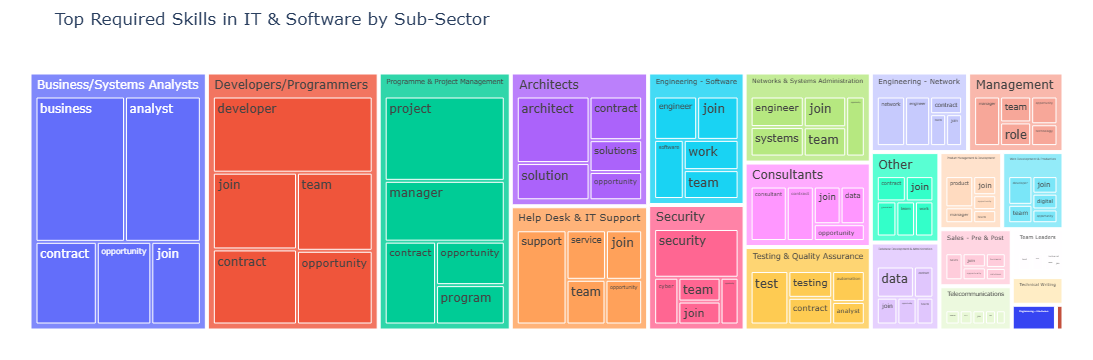

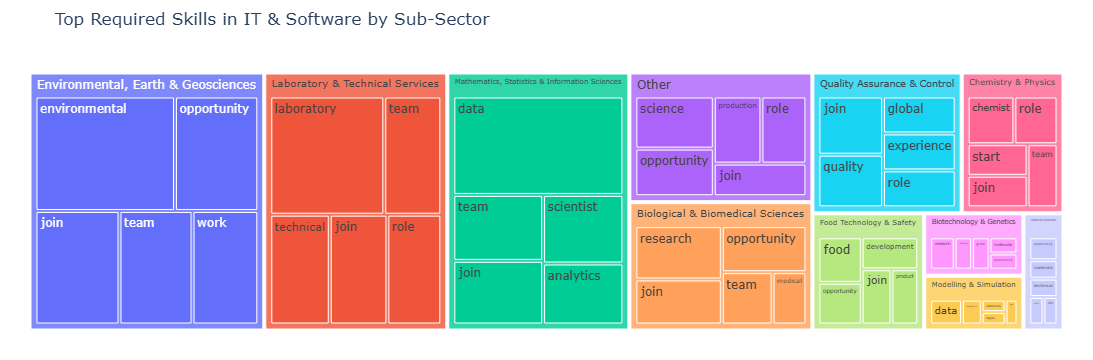

In [35]:
stopwords = set(['and','or','with','to','of','the','in','for','on','a','an'])

it_df = df[df['Classification'] == 'Information & Communication Technology'].dropna(subset=['SubClassification', 'Requirement'])

records = []
for subsector, group in it_df.groupby('SubClassification'):
    words = [
        w.strip('.,;()[]')
        for txt in group['Requirement'].str.lower()
        for w in txt.split()
        if w not in stopwords and len(w) > 3
    ]
    for skill, cnt in Counter(words).most_common(5):
        records.append({
            'SubSector': subsector,
            'Skill': skill,
            'Count': cnt
        })

skill_it_df = pd.DataFrame(records)

fig = px.treemap(skill_it_df, path=['SubSector', 'Skill'], values='Count', title='Top Required Skills in IT & Software by Sub-Sector')
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig.show()

it_df = df[df['Classification'] == 'Science & Technology'].dropna(subset=['SubClassification', 'Requirement'])

records = []
for subsector, group in it_df.groupby('SubClassification'):
    words = [
        w.strip('.,;()[]')
        for txt in group['Requirement'].str.lower()
        for w in txt.split()
        if w not in stopwords and len(w) > 3
    ]
    for skill, cnt in Counter(words).most_common(5):
        records.append({
            'SubSector': subsector,
            'Skill': skill,
            'Count': cnt
        })

skill_it_df = pd.DataFrame(records)

fig = px.treemap(skill_it_df, path=['SubSector', 'Skill'], values='Count', title='Top Required Skills in IT & Software by Sub-Sector')
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig.show()

Mathew, a first-year Computer Science student, aspires to become a skilled professional in a high-demand field. To achieve this, he should develop a versatile skill set that aligns with the growing need for expertise in data-driven and digital roles. According to the job market analysis the Information & Communication Technology sector dominates, with sub-sectors like Engineering - Software and Networks & Systems Administration being prominent. Other fields, such as Business/Systems Analysts, Project Management, and Help Desk & IT Support, frequently mention keywords like "systems", "management", "support", and "consultant", indicating that a Computer Science background can be applied across diverse roles.

Mathew should aim for flexibility rather than focusing solely on a single technical path. Being a well-rounded professional means mastering skills that span multiple contexts. For example, understanding how to join a team as a developer or engineer in software projects is crucial, while also being adept in data analysis and systems management. Fields like security and project management value skills such as solution design, teamwork, and communication, which complement technical expertise in areas like software development and database systems. The top 15 keywords across sectors support this approach: in Information & Communication Technology, terms like "developer", "software", and "engineer" highlight the need for coding proficiency, while in Science & Technology, keywords like "data", "analyst", and "research" emphasize analytical thinking. To succeed, Mathew should build a strong foundation in both technical skills (e.g., programming, systems design) and soft skills (e.g., collaboration, opportunity identification), enabling him to contribute effectively to team-based projects and adapt to various professional environments.

## Case Study 2 

To address TalentFinders' goal of matching candidates with suitable job opportunities, a recommender system can be developed using the job market dataset, which includes attributes like job sector (Classification), skills (Requirement), salary ranges (LowestSalary, HighestSalary), and location (Location). The system should identify the top-10 jobs for a candidate based on their profile, which includes their preferred sector, skills, experience level, and location preferences. A content-based filtering approach is well-suited for this task, as it can compare the candidate’s profile directly with job attributes to calculate similarity scores and rank the most relevant opportunities.
The process would begin by preprocessing the dataset to extract and standardize key features. For instance, skills can be extracted from the Requirement column using natural language processing techniques, such as keyword extraction or TF-IDF vectorization, to represent the textual data numerically. The candidate’s skills (e.g., "Python, data analysis") would be similarly processed to create a comparable profile. The sector and location can be matched by filtering jobs that align with the candidate’s preferences (e.g., "Information & Communication Technology" in "Sydney"). Experience can be inferred from salary ranges, assuming higher salaries correlate with more senior roles—candidates can specify a desired salary range to filter jobs. A similarity metric, such as cosine similarity, can then be applied to rank jobs based on how closely they match the candidate’s skills, sector, and salary expectations. Additional filters, like location or job type, can refine the results. The top-10 jobs with the highest similarity scores would be presented to the candidate, ensuring relevance to their profile. To enhance the system, weights could be assigned to different features (e.g., prioritizing skills over salary), and collaborative filtering could be explored if user feedback or historical matching data becomes available, allowing the system to improve over time.